# FMU on the Norwegian Continental Shelf

## From published Norne data to reservoir simulation, ERT update and NeqSim facilities

[Open this notebook in Google Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/fmu_norne_subsurface_to_facilities_workflow.ipynb)

This long-form tutorial follows a traceable oil-and-gas workflow:

**published NCS data → grid-property quality control → runnable reservoir model →
FMU/ERT ensemble update → posterior production forecast → NeqSim process model →
facility constraints → feedback to subsurface decisions.**

The static properties and well locations come from the public **Norne full-field
benchmark**, an actual Norwegian Sea field model released for research and education.
The notebook downloads immutable files from a pinned OPM data commit and stores checksums.

> **Important terminology:** FMU means **Fast Model Update** here. It does not mean the
> Functional Mock-up Unit used by the FMI co-simulation standard.

The reduced reservoir solver is deliberately transparent and portable. It uses the
published Norne porosity, permeability, net-to-gross, initial water saturation, active-cell
mask and published well grid locations. It is an educational two-phase finite-volume
upscaling of the full black-oil model, not a reproduction of the official Norne history
match. The full OPM Flow deck remains the reference for field-scale black-oil simulation.

## Learning outcomes

After completing the notebook, you should be able to:

1. explain where FMU sits in a subsurface-to-facilities workflow;
2. retrieve and verify a published NCS reservoir dataset;
3. interpret Eclipse/OPM grid keywords and their units;
4. upscale a 3D corner-point property model to a portable 2D teaching model;
5. formulate and run a sequential finite-volume pressure/saturation calculation;
6. check phase inventory, rates, pressure ordering and numerical bounds;
7. construct an FMU prior ensemble and update it with ES-MDA;
8. generate an ERT-compatible case contract and lint it;
9. pass posterior reservoir rates and pressures into a real NeqSim process model; and
10. turn facility constraints into subsurface control feedback.

### What is published and what is educational?

| Item | Status in this notebook |
|---|---|
| Norne grid dimensions, property arrays and active cells | Published OPM data |
| C-4H, B-2H and D-1H grid locations | Published Norne schedule |
| Full black-oil reference deck | Published, downloaded and inspected |
| Layer thickness, regular cell dimensions and two-phase controls | Educational assumptions |
| Portable finite-volume model | Implemented and run here |
| History observations | Synthetic, generated from a hidden parameter case |
| ES-MDA update | Real open-source algorithm from `iterative-ensemble-smoother` |
| Facility model | Real NeqSim SRK flash and process equipment |

In [1]:
import importlib.metadata
import importlib.util
import os
from pathlib import Path
import subprocess
import sys


os.environ.setdefault("MPLCONFIGDIR", "/tmp/neqsim_fmu_matplotlib")

REQUIRED_PACKAGES = {
    "neqsim": "3.16.0",
    "ert": "23.0.1",
    "iterative-ensemble-smoother": "1.3.0",
    "fmu-dataio": "2.30.2",
    "fmu-tools": "1.33.0",
}


def installed_version(package_name):
    try:
        return importlib.metadata.version(package_name)
    except importlib.metadata.PackageNotFoundError:
        return None


packages_to_install = [
    f"{package_name}=={required_version}"
    for package_name, required_version in REQUIRED_PACKAGES.items()
    if installed_version(package_name) != required_version
]
if packages_to_install:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            *packages_to_install,
        ],
        check=True,
        timeout=1200,
    )

python_bin_directory = str(Path(sys.executable).parent)
os.environ["PATH"] = (
    python_bin_directory
    + os.pathsep
    + os.environ.get("PATH", "")
)

print("Runtime dependencies are ready.")

Runtime dependencies are ready.


In [2]:
import hashlib
import json
import math
import platform
import re
import shutil
import textwrap
import urllib.request

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd
from scipy.sparse import coo_matrix, diags
from scipy.sparse.linalg import spsolve
from iterative_ensemble_smoother import ESMDA


plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

RANDOM_SEED = 20260820
rng = np.random.default_rng(RANDOM_SEED)
ARTIFACT_DIRECTORY = Path("norne_fmu_workflow_artifacts")
DATA_DIRECTORY = ARTIFACT_DIRECTORY / "published_norne_data"
ARTIFACT_DIRECTORY.mkdir(exist_ok=True)
DATA_DIRECTORY.mkdir(exist_ok=True)

runtime_versions = pd.DataFrame(
    {
        "component": [
            "Python",
            "NeqSim",
            "ERT",
            "iterative-ensemble-smoother",
            "fmu-dataio",
            "fmu-tools",
        ],
        "version": [
            platform.python_version(),
            installed_version("neqsim"),
            installed_version("ert"),
            installed_version("iterative-ensemble-smoother"),
            installed_version("fmu-dataio"),
            installed_version("fmu-tools"),
        ],
    }
)
display(runtime_versions)

,component,version
0,Python,3.12.13
1,NeqSim,3.16.0
2,ERT,23.0.1
3,iterative-ensemble-smoother,1.3.0
4,fmu-dataio,2.30.2
5,fmu-tools,1.33.0


## 1. Where FMU sits in the work process

FMU is not a single reservoir simulator. It is a governed workflow around uncertain
models, forward simulations, observations, updates, quality control and reusable results.
ERT typically orchestrates realizations and performs the ensemble update. OPM Flow or
another physics simulator is the reservoir forward model. `fmu-dataio` standardizes files
and metadata, while `fmu-tools` supports preprocessing, postprocessing and QC.

The handover to NeqSim occurs after each reservoir realization has produced time-indexed
rates, pressures, temperatures and fluid descriptions. NeqSim then calculates phase
behavior, separation, compression, water handling, export conditions and constraints.

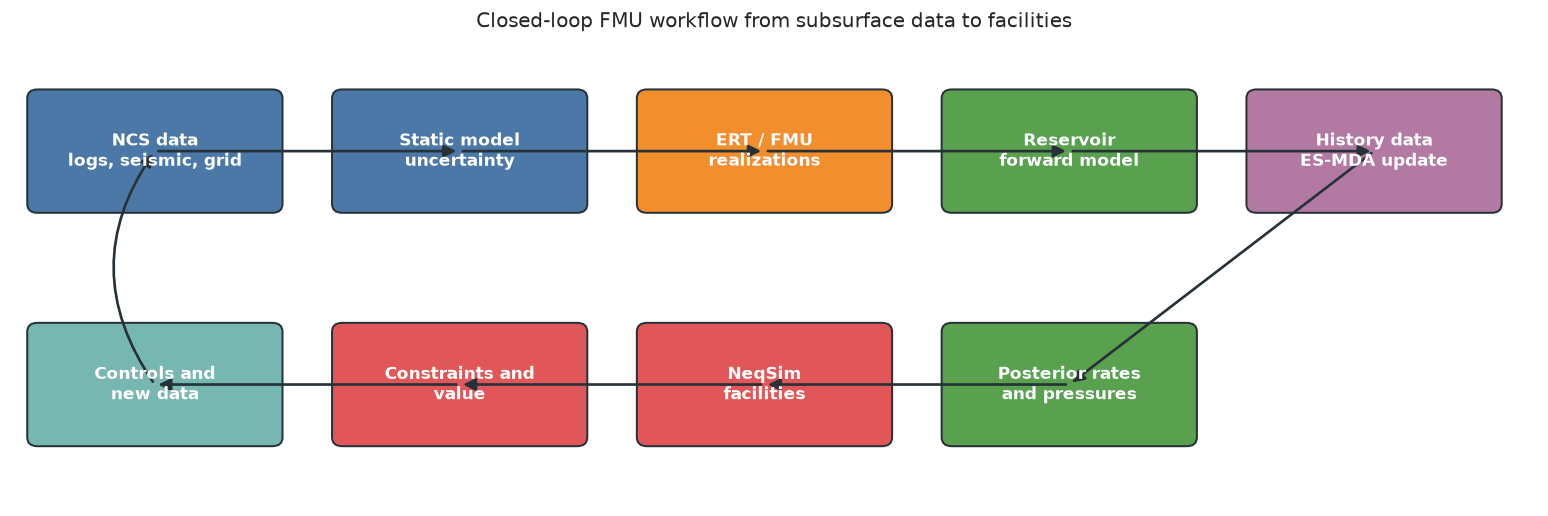

In [3]:
workflow_nodes = [
    (0.2, 2.7, "NCS data\nlogs, seismic, grid", "#4C78A8"),
    (2.6, 2.7, "Static model\nuncertainty", "#4C78A8"),
    (5.0, 2.7, "ERT / FMU\nrealizations", "#F28E2B"),
    (7.4, 2.7, "Reservoir\nforward model", "#59A14F"),
    (9.8, 2.7, "History data\nES-MDA update", "#B279A2"),
    (7.4, 0.6, "Posterior rates\nand pressures", "#59A14F"),
    (5.0, 0.6, "NeqSim\nfacilities", "#E15759"),
    (2.6, 0.6, "Constraints and\nvalue", "#E15759"),
    (0.2, 0.6, "Controls and\nnew data", "#76B7B2"),
]

figure, axis = plt.subplots(figsize=(13, 4.4))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.2)
axis.axis("off")

for x_position, y_position, label, color in workflow_nodes:
    box = FancyBboxPatch(
        (x_position, y_position),
        1.85,
        0.95,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="#263238",
        linewidth=1.2,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 0.925,
        y_position + 0.475,
        label,
        color="white",
        ha="center",
        va="center",
        weight="bold",
    )

node_centres = [
    (1.125, 3.175),
    (3.525, 3.175),
    (5.925, 3.175),
    (8.325, 3.175),
    (10.725, 3.175),
    (8.325, 1.075),
    (5.925, 1.075),
    (3.525, 1.075),
    (1.125, 1.075),
]
for start, end in zip(node_centres[:-1], node_centres[1:]):
    axis.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.6,
            color="#263238",
            connectionstyle="arc3,rad=0.0",
        )
    )

axis.add_patch(
    FancyArrowPatch(
        node_centres[-1],
        node_centres[0],
        arrowstyle="-|>",
        mutation_scale=15,
        linewidth=1.6,
        color="#263238",
        connectionstyle="arc3,rad=-0.35",
    )
)
axis.set_title("Closed-loop FMU workflow from subsurface data to facilities")
figure.tight_layout()
plt.show()

## 2. Published Norwegian Continental Shelf data

The main source is the OPM `opm-data` Norne model at commit
`eaa2261683a97027e057c2bc49612ad1c86390b3`. The commit pin prevents a future
branch change from silently changing this calculation.

| Source | Use here | License / provenance |
|---|---|---|
| [OPM Norne dataset](https://github.com/OPM/opm-data/tree/eaa2261683a97027e057c2bc49612ad1c86390b3/norne) | Full deck, grid properties and schedule | ODbL/DbCL notices embedded in files; copyright Statoil 2015 |
| [OPM open datasets](https://opm-project.org/?page_id=559) | Confirms Norne is a real Norwegian Sea black-oil case | OPM project documentation |
| [Norne benchmark at NTNU](https://www.ipt.ntnu.no/~norne/wiki1/doku.php?id=english:start) | Benchmark context | NTNU IO Center |
| [ERT history-matching introduction](https://ert.readthedocs.io/en/latest/theory/gentle_introduction_to_history_matching.html) | ES-MDA concepts | Equinor ERT documentation |
| [fmu-dataio](https://fmu-dataio.readthedocs.io/en/latest/overview.html) | FMU file and metadata conventions | Equinor documentation |
| [OPM Flow](https://opm-project.org/?page_id=19) | Full black-oil simulator path | OPM documentation |
| [NeqSim](https://equinor.github.io/neqsimhome/) | Thermodynamics and facilities | Equinor open-source project |

The downloadable model contains `46 × 112 × 22 = 113,344` grid cells. We use the
published `PORO`, `PERMX`, `NTG`, `SWATINIT` and `ACTNUM` arrays. We also parse the first
`WELSPECS` block in the public history schedule to obtain actual Norne grid locations for
wells C-4H, B-2H and D-1H.

In [4]:
OPM_DATA_COMMIT = "eaa2261683a97027e057c2bc49612ad1c86390b3"
RAW_ROOT = (
    "https://raw.githubusercontent.com/OPM/opm-data/"
    f"{OPM_DATA_COMMIT}/norne"
)

source_files = {
    "NORNE_ATW2013.DATA": "NORNE_ATW2013.DATA",
    "PORO_0704.prop": "INCLUDE/PETRO/PORO_0704.prop",
    "PERM_0704.prop": "INCLUDE/PETRO/PERM_0704.prop",
    "NTG_0704.prop": "INCLUDE/PETRO/NTG_0704.prop",
    "SWINITIAL.INC": "INCLUDE/PETRO/SWINITIAL.INC",
    "ACTNUM_0704.prop": "INCLUDE/GRID/ACTNUM_0704.prop",
    "BC0407_HIST01122006.SCH": "INCLUDE/BC0407_HIST01122006.SCH",
}

download_rows = []
for local_name, repository_path in source_files.items():
    destination = DATA_DIRECTORY / local_name
    source_url = f"{RAW_ROOT}/{repository_path}"
    if not destination.exists():
        urllib.request.urlretrieve(source_url, destination)
    file_bytes = destination.read_bytes()
    download_rows.append(
        {
            "file": local_name,
            "bytes": len(file_bytes),
            "sha256": hashlib.sha256(file_bytes).hexdigest(),
            "source": source_url,
        }
    )

source_manifest = pd.DataFrame(download_rows)
display(source_manifest[["file", "bytes", "sha256"]])

,file,bytes,sha256
0,NORNE_ATW2013.DATA,12129,f346c910f68a80b41ee54606bd434dc9e2993fffa7a246...
1,PORO_0704.prop,1838473,e5147647a2fbee651b9df27e1db4a7a70e8b3ee8231b92...
2,PERM_0704.prop,1838474,bce56f7ff702dffe6ae2837bdda4ab4f6fa1d54c0be178...
3,NTG_0704.prop,1838472,b5b6a556f0edf6d9767a418adcba3a2821359fdf8ce374...
4,SWINITIAL.INC,1983942,e93357c814bac4b87d6d7f21c71d33a7eea20690ccecb3...
5,ACTNUM_0704.prop,229483,32e590467b04ca31e487a94d62ff6e91ffb87844ad2af5...
6,BC0407_HIST01122006.SCH,462215,48e445fd884306c25804edde330ea7a590624fb43ac93e...


In [5]:
deck_text = (DATA_DIRECTORY / "NORNE_ATW2013.DATA").read_text(
    encoding="utf-8"
)
license_lines = "\n".join(deck_text.splitlines()[:7])
dimensions_match = re.search(
    r"DIMENS\s+(\d+)\s+(\d+)\s+(\d+)",
    deck_text,
    flags=re.MULTILINE,
)
if dimensions_match is None:
    raise RuntimeError("DIMENS was not found in the published Norne deck.")

NX, NY, NZ = [int(value) for value in dimensions_match.groups()]
print(license_lines)
print(f"\nParsed grid dimensions: {NX} × {NY} × {NZ}")

-- This reservoir simulation deck is made available under the Open Database
-- License: http://opendatacommons.org/licenses/odbl/1.0/. Any rights in
-- individual contents of the database are licensed under the Database Contents
-- License: http://opendatacommons.org/licenses/dbcl/1.0/

-- Copyright (C) 2015 Statoil


Parsed grid dimensions: 46 × 112 × 22


## 3. From logs and seismic to simulator properties

In a field workflow, the published grid arrays are not primary measurements. They are the
end product of an interpretation chain:

| Measurement / interpretation | Typical Python tool | Reservoir-model output |
|---|---|---|
| LAS/DLIS logs | `lasio`, `welly` | porosity, saturation, facies, permeability transforms |
| Checkshot/VSP and SEG-Y | `segyio`, SciPy | depth-time relation, horizons and faults |
| Geostatistics and geomodelling | `gstools`, `xtgeo`, commercial geomodellers | 3D realizations of facies and properties |
| Upscaling | `xtgeo`, OPM upscaling, custom QC | cell-scale `PORO`, `PERMX`, `NTG`, saturation functions |
| Dynamic initialization | OPM Flow or another simulator | pressure, saturation and fluid state |

The familiar petrophysical equations still sit upstream. Examples include density
porosity and Archie water saturation:

$$\phi_D=\frac{\rho_{ma}-\rho_b}{\rho_{ma}-\rho_f}$$

$$S_w=\left(\frac{aR_w}{\phi^mR_t}\right)^{1/n}$$

Here $\rho_{ma}$, $\rho_b$ and $\rho_f$ are matrix, bulk and fluid densities;
$R_w$ and $R_t$ are water and true formation resistivities; and $a$, $m$ and $n$ are
Archie parameters. The Norne property files are downstream results. We therefore inspect
and use them without pretending to reconstruct the proprietary interpretation history.

In [6]:
def parse_grdecl_keyword(path, keyword, shape):
    text = Path(path).read_text(encoding="utf-8")
    text_without_comments = "\n".join(
        line.split("--")[0]
        for line in text.splitlines()
    )
    if keyword not in text_without_comments:
        raise KeyError(f"{keyword} was not found in {path}.")
    value_text = text_without_comments.split(keyword, 1)[1].split("/", 1)[0]
    values = []
    for token in value_text.split():
        if "*" in token:
            count_text, value_text_token = token.split("*", 1)
            repeated_value = float(value_text_token or 0.0)
            values.extend([repeated_value] * int(count_text))
        else:
            values.append(float(token))
    array = np.asarray(values, dtype=float)
    expected_size = int(np.prod(shape))
    if array.size != expected_size:
        raise ValueError(
            f"{keyword} has {array.size} values; expected {expected_size}."
        )
    return array.reshape(shape, order="F")


grid_shape = (NX, NY, NZ)
porosity_3d = parse_grdecl_keyword(
    DATA_DIRECTORY / "PORO_0704.prop",
    "PORO",
    grid_shape,
)
permeability_3d_md = parse_grdecl_keyword(
    DATA_DIRECTORY / "PERM_0704.prop",
    "PERMX",
    grid_shape,
)
ntg_3d = parse_grdecl_keyword(
    DATA_DIRECTORY / "NTG_0704.prop",
    "NTG",
    grid_shape,
)
sw_initial_3d = parse_grdecl_keyword(
    DATA_DIRECTORY / "SWINITIAL.INC",
    "SWATINIT",
    grid_shape,
)
actnum_3d = parse_grdecl_keyword(
    DATA_DIRECTORY / "ACTNUM_0704.prop",
    "ACTNUM",
    grid_shape,
)

active_3d = actnum_3d > 0.5
property_summary = pd.DataFrame(
    {
        "property": ["PORO", "PERMX", "NTG", "SWATINIT", "ACTNUM"],
        "unit": ["fraction", "mD", "fraction", "fraction", "flag"],
        "minimum_active": [
            porosity_3d[active_3d].min(),
            permeability_3d_md[active_3d].min(),
            ntg_3d[active_3d].min(),
            sw_initial_3d[active_3d].min(),
            actnum_3d[active_3d].min(),
        ],
        "median_active": [
            np.median(porosity_3d[active_3d]),
            np.median(permeability_3d_md[active_3d]),
            np.median(ntg_3d[active_3d]),
            np.median(sw_initial_3d[active_3d]),
            np.median(actnum_3d[active_3d]),
        ],
        "maximum_active": [
            porosity_3d[active_3d].max(),
            permeability_3d_md[active_3d].max(),
            ntg_3d[active_3d].max(),
            sw_initial_3d[active_3d].max(),
            actnum_3d[active_3d].max(),
        ],
    }
)
display(property_summary.round(5))
print(f"Active 3D cells: {active_3d.sum():,} of {active_3d.size:,}")

Active 3D cells: 44,927 of 113,344


,property,unit,minimum_active,median_active,maximum_active
0,PORO,fraction,0.09421,0.24470,0.34732
1,PERMX,mD,0.32211,209.91348,3996.54761
2,NTG,fraction,0.00667,0.93113,1.00000
3,SWATINIT,fraction,0.00000,0.53608,1.00000
4,ACTNUM,flag,1.00000,1.00000,1.00000


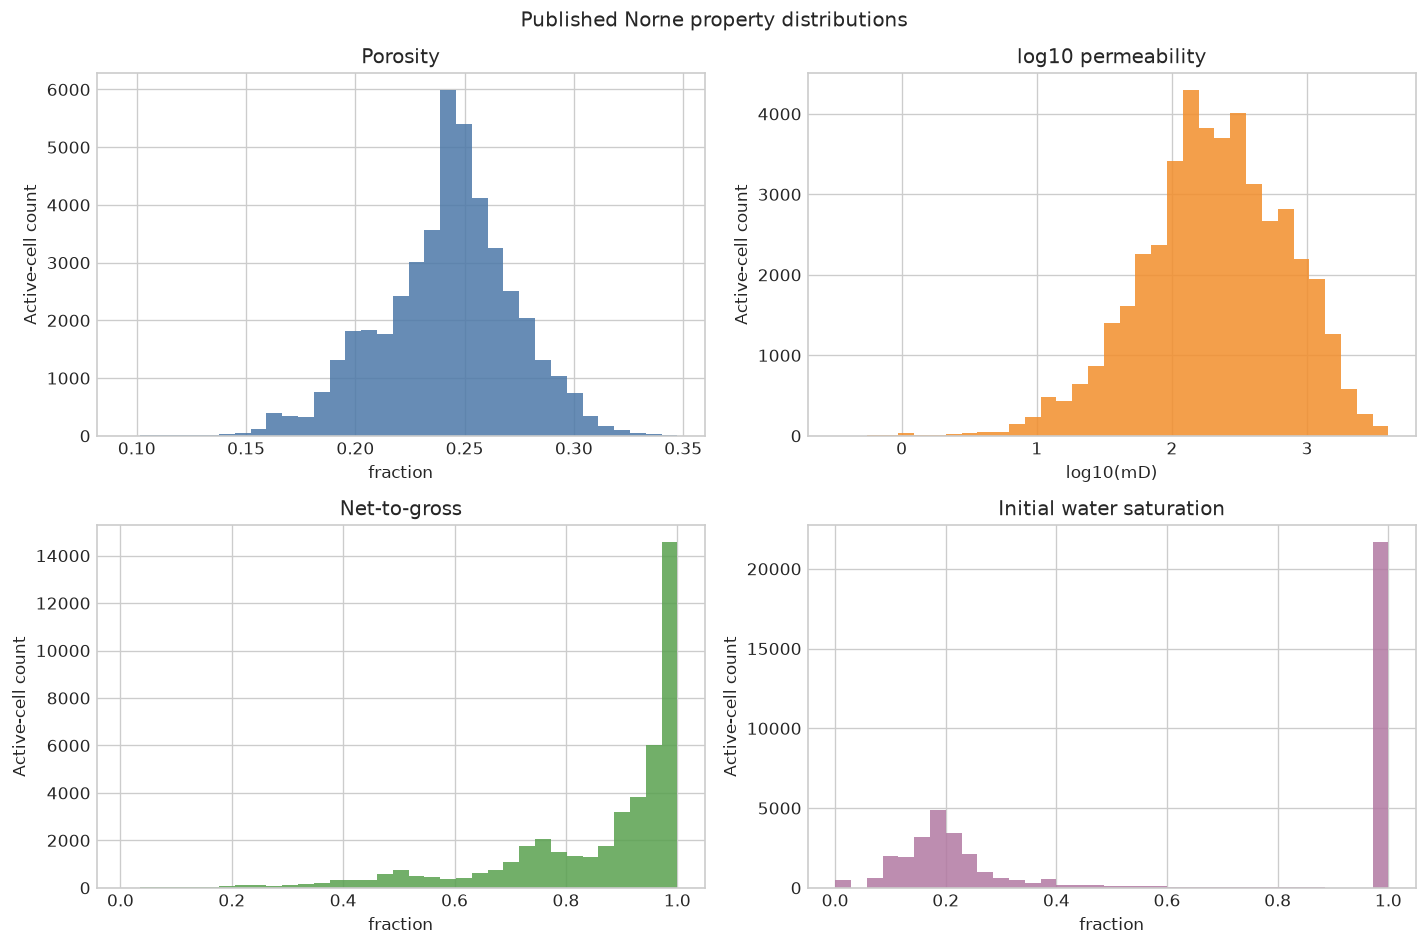

In [7]:
figure, axes = plt.subplots(2, 2, figsize=(12, 8))
plot_specs = [
    (porosity_3d[active_3d], "Porosity", "fraction", "#4C78A8"),
    (
        np.log10(np.maximum(permeability_3d_md[active_3d], 1.0e-4)),
        "log10 permeability",
        "log10(mD)",
        "#F28E2B",
    ),
    (ntg_3d[active_3d], "Net-to-gross", "fraction", "#59A14F"),
    (
        sw_initial_3d[active_3d],
        "Initial water saturation",
        "fraction",
        "#B279A2",
    ),
]
for axis, (values, title, x_label, color) in zip(axes.flat, plot_specs):
    axis.hist(values, bins=35, color=color, alpha=0.85)
    axis.set_title(title)
    axis.set_xlabel(x_label)
    axis.set_ylabel("Active-cell count")
figure.suptitle("Published Norne property distributions")
figure.tight_layout()
plt.show()

## 4. Published well locations from the Norne schedule

The first `WELSPECS` block defines three wells. C-4H is later controlled as a gas injector,
while B-2H and D-1H are producers in the history schedule. The coordinates below are
**one-based Eclipse indices** in the source and are converted to zero-based NumPy indices.

We use their published locations but apply simplified balanced fluid controls in the
portable model. This keeps the calculation stable and makes the conservation check clear;
it is not a history replay.

In [8]:
schedule_text = (
    DATA_DIRECTORY / "BC0407_HIST01122006.SCH"
).read_text(encoding="utf-8")
first_welspecs_block = schedule_text.split("WELSPECS", 1)[1].split("/\n/", 1)[0]
well_pattern = re.compile(
    r"'(?P<well>[^']+)'\s+'(?P<group>[^']+)'\s+"
    r"(?P<i>\d+)\s+(?P<j>\d+)"
)
well_rows = []
for match in well_pattern.finditer(first_welspecs_block):
    well_rows.append(
        {
            "well": match.group("well"),
            "group": match.group("group"),
            "i_eclipse": int(match.group("i")),
            "j_eclipse": int(match.group("j")),
        }
    )
wells = pd.DataFrame(well_rows).drop_duplicates("well")
expected_wells = {"C-4H", "B-2H", "D-1H"}
if not expected_wells.issubset(set(wells["well"])):
    raise RuntimeError("Expected Norne wells were not parsed from WELSPECS.")
wells = wells[wells["well"].isin(expected_wells)].reset_index(drop=True)
display(wells)

,well,group,i_eclipse,j_eclipse
0,C-4H,MANI-C,11,35
1,B-2H,B1-DUMMY,15,31
2,D-1H,MANI-D1,22,22


## 5. Vertical upscaling to a portable reservoir model

The full Norne deck uses a faulted corner-point grid and many black-oil features. For a
portable Colab demonstration, we vertically collapse each active $(i,j)$ column.

With educational layer thickness $h_k=5$ m, the column pore volume is

$$PV_{ij}=\Delta x\Delta y\sum_k A_{ijk}h_kNTG_{ijk}\phi_{ijk}$$

and the thickness-weighted porosity is

$$\bar{\phi}_{ij}=\frac{\sum_k A_{ijk}h_kNTG_{ijk}\phi_{ijk}}{\sum_k A_{ijk}h_kNTG_{ijk}}$$

Here $A_{ijk}$ is the active-cell flag. Horizontal permeability is arithmetic thickness
weighted because layers act approximately in parallel. A full upscaling study would retain
corner-point geometry, faults, directional permeability, relative permeability and
capillary pressure.

In [9]:
CELL_SIZE_X_M = 100.0
CELL_SIZE_Y_M = 100.0
EDUCATIONAL_LAYER_THICKNESS_M = 5.0

thickness_weight_3d = (
    actnum_3d
    * ntg_3d
    * EDUCATIONAL_LAYER_THICKNESS_M
)
gross_active_thickness_m = np.sum(
    actnum_3d * EDUCATIONAL_LAYER_THICKNESS_M,
    axis=2,
)
net_thickness_m = np.sum(thickness_weight_3d, axis=2)
active_columns = net_thickness_m > 0.0

porosity_2d = np.divide(
    np.sum(porosity_3d * thickness_weight_3d, axis=2),
    net_thickness_m,
    out=np.zeros((NX, NY)),
    where=active_columns,
)
permeability_2d_md = np.divide(
    np.sum(permeability_3d_md * thickness_weight_3d, axis=2),
    net_thickness_m,
    out=np.zeros((NX, NY)),
    where=active_columns,
)
water_storage_weight = porosity_3d * thickness_weight_3d
sw_initial_2d = np.divide(
    np.sum(sw_initial_3d * water_storage_weight, axis=2),
    np.sum(water_storage_weight, axis=2),
    out=np.full((NX, NY), 0.22),
    where=np.sum(water_storage_weight, axis=2) > 0.0,
)
sw_initial_2d = np.clip(sw_initial_2d, 0.12, 0.82)

pore_volume_2d_m3 = (
    CELL_SIZE_X_M
    * CELL_SIZE_Y_M
    * np.sum(water_storage_weight, axis=2)
)

upscaled_summary = pd.DataFrame(
    {
        "quantity": [
            "Active 2D columns",
            "Educational pore volume",
            "PV-weighted porosity",
            "Median horizontal permeability",
            "PV-weighted initial water saturation",
        ],
        "value": [
            int(active_columns.sum()),
            pore_volume_2d_m3.sum() / 1.0e6,
            np.average(
                porosity_2d[active_columns],
                weights=pore_volume_2d_m3[active_columns],
            ),
            np.median(permeability_2d_md[active_columns]),
            np.average(
                sw_initial_2d[active_columns],
                weights=pore_volume_2d_m3[active_columns],
            ),
        ],
        "unit": ["count", "million m³", "fraction", "mD", "fraction"],
    }
)
display(upscaled_summary.round(5))

,quantity,value,unit
0,Active 2D columns,2263.00000,count
1,Educational pore volume,473.33060,million m³
2,PV-weighted porosity,0.24642,fraction
3,Median horizontal permeability,390.70473,mD
4,PV-weighted initial water saturation,0.52386,fraction


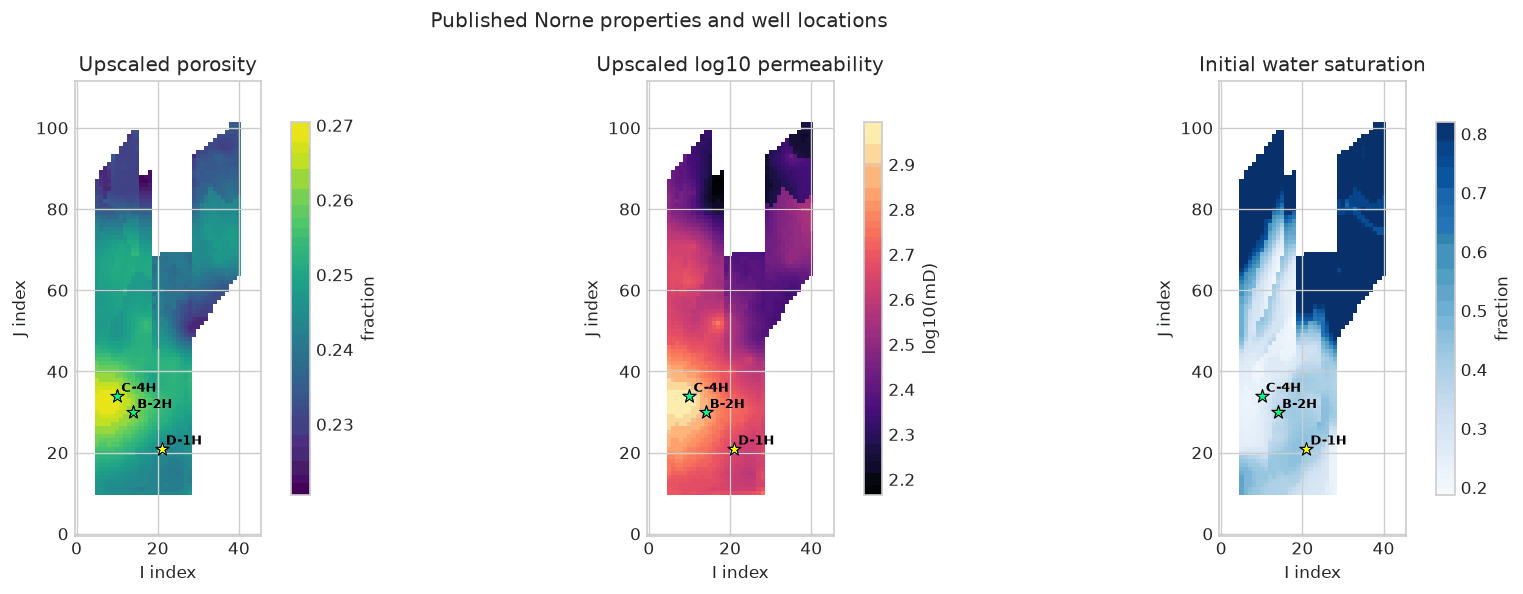

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(15, 5))
map_specs = [
    (porosity_2d, "Upscaled porosity", "fraction", "viridis"),
    (
        np.log10(np.maximum(permeability_2d_md, 0.1)),
        "Upscaled log10 permeability",
        "log10(mD)",
        "magma",
    ),
    (sw_initial_2d, "Initial water saturation", "fraction", "Blues"),
]
for axis, (values, title, unit, color_map) in zip(axes, map_specs):
    masked_values = np.ma.masked_where(~active_columns, values)
    image = axis.imshow(
        masked_values.T,
        origin="lower",
        aspect="equal",
        cmap=color_map,
    )
    axis.set_title(title)
    axis.set_xlabel("I index")
    axis.set_ylabel("J index")
    colorbar = figure.colorbar(image, ax=axis, shrink=0.82)
    colorbar.set_label(unit)

well_colors = {"C-4H": "cyan", "B-2H": "lime", "D-1H": "yellow"}
for axis in axes:
    for row in wells.itertuples(index=False):
        x_index = row.i_eclipse - 1
        y_index = row.j_eclipse - 1
        axis.scatter(
            x_index,
            y_index,
            s=70,
            marker="*",
            color=well_colors[row.well],
            edgecolor="black",
            linewidth=0.7,
        )
        axis.text(
            x_index + 1.0,
            y_index + 1.0,
            row.well,
            color="black",
            fontsize=8,
            weight="bold",
        )
figure.suptitle("Published Norne properties and well locations")
figure.tight_layout()
plt.show()

## 6. Reservoir equations and numerical method

We solve pressure implicitly and water saturation explicitly. For each active column,
total compressibility provides pressure storage:

$$\frac{PV_i c_t}{\Delta t}(p_i^{n+1}-p_i^n)+\sum_jT_{ij}(p_i^{n+1}-p_j^{n+1})=q_i$$

The phase mobilities and water fractional flow are

$$\lambda_w=\frac{k_{rw}}{\mu_w},\quad\lambda_o=\frac{k_{ro}}{\mu_o},\quad f_w=\frac{\lambda_w}{\lambda_w+\lambda_o}$$

with Corey relative permeabilities applied to normalized saturation. Water inventory is
advanced from upwinded face fluxes and well terms. Pressure is absolute in bara, rates are
standard cubic metres per day, permeability is mD and time is days.

This is a sequential-implicit educational model. It omits gas, dissolved gas, capillary
pressure, gravity, faults and the exact corner-point geometry used by full OPM Flow.

In [11]:
active_ids = -np.ones((NX, NY), dtype=int)
active_ids[active_columns] = np.arange(active_columns.sum())

edge_left = []
edge_right = []
edge_base_transmissibility = []
neighbor_specs = [
    (1, 0, CELL_SIZE_Y_M, CELL_SIZE_X_M),
    (0, 1, CELL_SIZE_X_M, CELL_SIZE_Y_M),
]
OIL_VISCOSITY_CP = 1.60

for i_index in range(NX):
    for j_index in range(NY):
        if not active_columns[i_index, j_index]:
            continue
        for delta_i, delta_j, face_width_m, cell_length_m in neighbor_specs:
            neighbor_i = i_index + delta_i
            neighbor_j = j_index + delta_j
            if neighbor_i >= NX or neighbor_j >= NY:
                continue
            if not active_columns[neighbor_i, neighbor_j]:
                continue
            left_id = active_ids[i_index, j_index]
            right_id = active_ids[neighbor_i, neighbor_j]
            left_kh = (
                permeability_2d_md[i_index, j_index]
                * net_thickness_m[i_index, j_index]
            )
            right_kh = (
                permeability_2d_md[neighbor_i, neighbor_j]
                * net_thickness_m[neighbor_i, neighbor_j]
            )
            harmonic_kh = (
                2.0
                * left_kh
                * right_kh
                / max(left_kh + right_kh, 1.0e-12)
            )
            transmissibility = (
                0.0864
                * harmonic_kh
                * face_width_m
                / (cell_length_m * OIL_VISCOSITY_CP)
            )
            edge_left.append(left_id)
            edge_right.append(right_id)
            edge_base_transmissibility.append(transmissibility)

edge_left = np.asarray(edge_left, dtype=int)
edge_right = np.asarray(edge_right, dtype=int)
edge_base_transmissibility = np.asarray(
    edge_base_transmissibility,
    dtype=float,
)
pore_volume_active_m3 = pore_volume_2d_m3[active_columns]

well_cells = {
    row.well: active_ids[row.i_eclipse - 1, row.j_eclipse - 1]
    for row in wells.itertuples(index=False)
}
if any(cell_id < 0 for cell_id in well_cells.values()):
    raise RuntimeError("A published well location is inactive after upscaling.")

print(f"Active model cells: {len(pore_volume_active_m3):,}")
print(f"Internal cell connections: {len(edge_left):,}")
print(f"Well-cell mapping: {well_cells}")

Active model cells: 2,263
Internal cell connections: 4,366
Well-cell mapping: {'C-4H': np.int64(429), 'B-2H': np.int64(771), 'D-1H': np.int64(1298)}


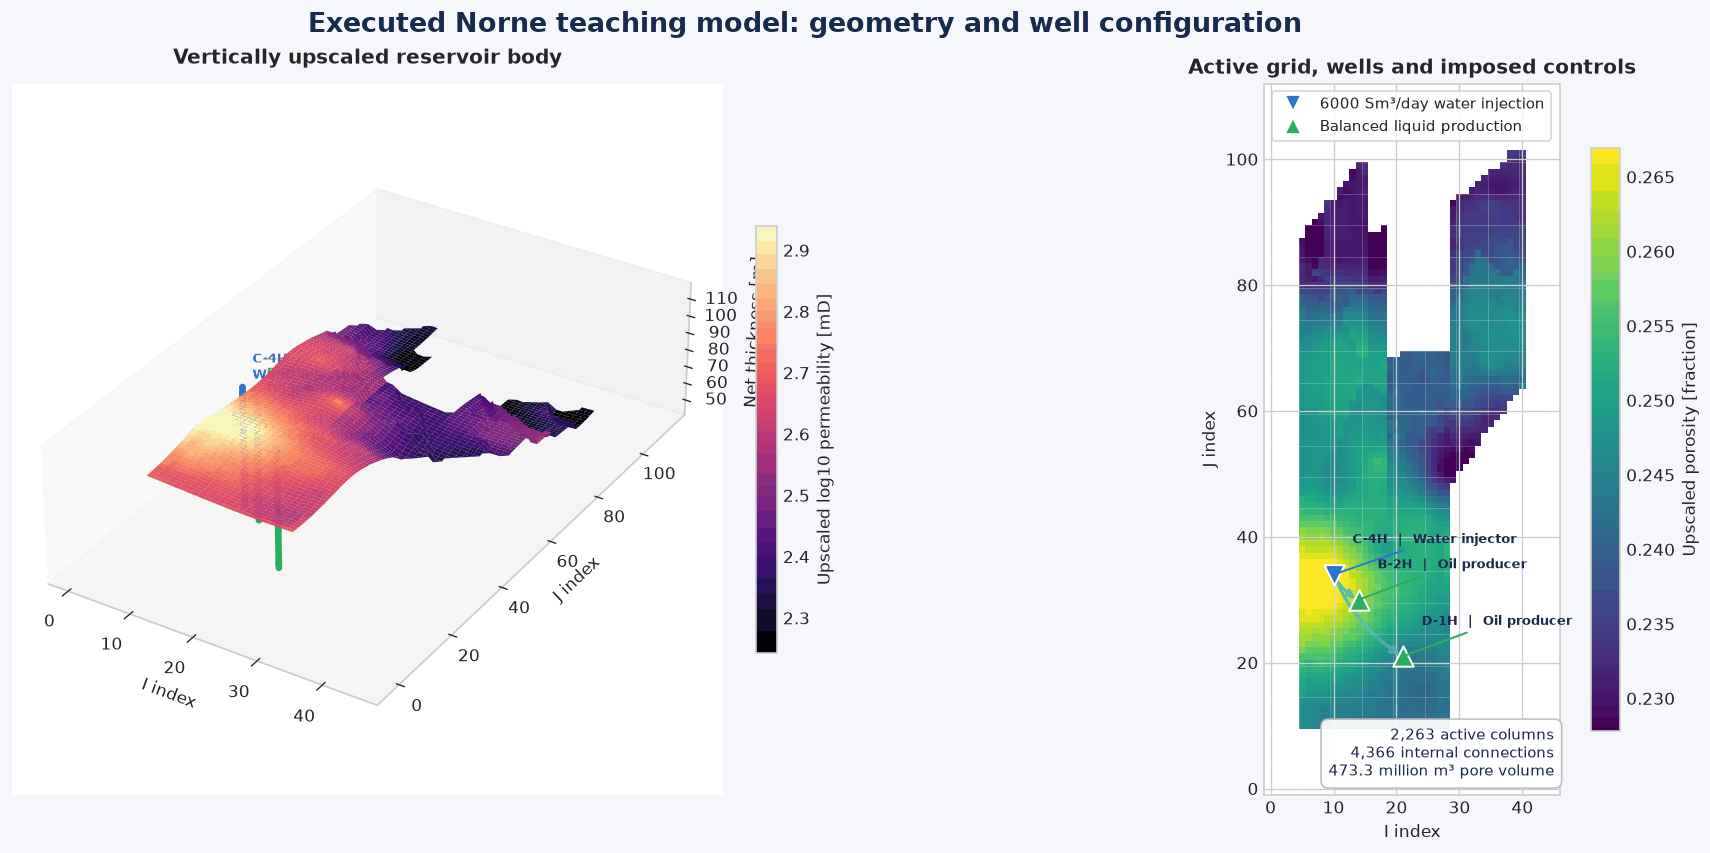

In [12]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D


i_grid, j_grid = np.meshgrid(
    np.arange(NX),
    np.arange(NY),
    indexing="ij",
)
thickness_surface = np.where(
    active_columns,
    net_thickness_m,
    np.nan,
)
log_permeability_map = np.where(
    active_columns,
    np.log10(np.maximum(permeability_2d_md, 1.0e-6)),
    np.nan,
)
permeability_norm = Normalize(
    vmin=np.nanpercentile(log_permeability_map, 2.0),
    vmax=np.nanpercentile(log_permeability_map, 98.0),
)
surface_colors = plt.cm.magma(
    permeability_norm(log_permeability_map)
)
surface_colors[~active_columns] = (0.0, 0.0, 0.0, 0.0)

model_figure = plt.figure(
    figsize=(15, 7),
    constrained_layout=True,
)
model_figure.patch.set_facecolor("#F5F7FA")
model_grid = model_figure.add_gridspec(
    1,
    2,
    width_ratios=[1.15, 1.0],
)
model_axis_3d = model_figure.add_subplot(
    model_grid[0, 0],
    projection="3d",
)
model_axis_2d = model_figure.add_subplot(model_grid[0, 1])

model_axis_3d.plot_surface(
    i_grid,
    j_grid,
    thickness_surface,
    facecolors=surface_colors,
    rstride=1,
    cstride=1,
    linewidth=0.08,
    edgecolor=(0.15, 0.15, 0.15, 0.20),
    antialiased=True,
    shade=False,
)
well_roles = {
    "C-4H": "Water injector",
    "B-2H": "Oil producer",
    "D-1H": "Oil producer",
}
role_colors = {
    "Water injector": "#2F80ED",
    "Oil producer": "#27AE60",
}
maximum_thickness = float(np.nanmax(thickness_surface))
for row in wells.itertuples(index=False):
    well_i = row.i_eclipse - 1
    well_j = row.j_eclipse - 1
    well_top = float(net_thickness_m[well_i, well_j])
    well_role = well_roles[row.well]
    well_color = role_colors[well_role]
    line_bottom = max(0.0, well_top - 0.45 * maximum_thickness)
    model_axis_3d.plot(
        [well_i, well_i],
        [well_j, well_j],
        [line_bottom, well_top + 0.25 * maximum_thickness],
        color=well_color,
        linewidth=4.0,
        solid_capstyle="round",
    )
    vertical_direction = -1.0 if well_role == "Water injector" else 1.0
    arrow_origin = (
        well_top + 0.20 * maximum_thickness
        if well_role == "Water injector"
        else well_top
    )
    model_axis_3d.quiver(
        well_i,
        well_j,
        arrow_origin,
        0.0,
        0.0,
        vertical_direction,
        length=0.18 * maximum_thickness,
        color=well_color,
        linewidth=2.5,
        arrow_length_ratio=0.35,
    )
    model_axis_3d.text(
        well_i + 1.2,
        well_j + 1.0,
        well_top + 0.30 * maximum_thickness,
        f"{row.well}\n{well_role}",
        color=well_color,
        fontsize=8,
        weight="bold",
    )

permeability_mappable = ScalarMappable(
    norm=permeability_norm,
    cmap="magma",
)
permeability_mappable.set_array([])
model_colorbar = model_figure.colorbar(
    permeability_mappable,
    ax=model_axis_3d,
    shrink=0.60,
    pad=0.04,
)
model_colorbar.set_label("Upscaled log10 permeability [mD]")
model_axis_3d.set_title(
    "Vertically upscaled reservoir body",
    pad=12,
    weight="bold",
)
model_axis_3d.set_xlabel("I index")
model_axis_3d.set_ylabel("J index")
model_axis_3d.set_zlabel("Net thickness [m]")
model_axis_3d.view_init(elev=32, azim=-58)
model_axis_3d.set_box_aspect((1.0, 1.6, 0.42))
model_axis_3d.grid(False)

footprint_image = model_axis_2d.imshow(
    np.ma.masked_where(~active_columns, porosity_2d).T,
    origin="lower",
    cmap="viridis",
    vmin=np.nanpercentile(porosity_2d[active_columns], 2.0),
    vmax=np.nanpercentile(porosity_2d[active_columns], 98.0),
)
for grid_index in range(0, NX + 1, 5):
    model_axis_2d.axvline(
        grid_index - 0.5,
        color="white",
        linewidth=0.35,
        alpha=0.35,
    )
for grid_index in range(0, NY + 1, 5):
    model_axis_2d.axhline(
        grid_index - 0.5,
        color="white",
        linewidth=0.35,
        alpha=0.35,
    )

injector_row = wells.loc[wells["well"] == "C-4H"].iloc[0]
injector_xy = (
    injector_row["i_eclipse"] - 1,
    injector_row["j_eclipse"] - 1,
)
for row in wells.itertuples(index=False):
    well_xy = (row.i_eclipse - 1, row.j_eclipse - 1)
    well_role = well_roles[row.well]
    well_color = role_colors[well_role]
    model_axis_2d.scatter(
        *well_xy,
        s=150,
        marker="v" if well_role == "Water injector" else "^",
        color=well_color,
        edgecolor="white",
        linewidth=1.2,
        zorder=5,
    )
    model_axis_2d.annotate(
        f"{row.well}  |  {well_role}",
        xy=well_xy,
        xytext=(well_xy[0] + 3.0, well_xy[1] + 5.0),
        fontsize=8,
        weight="bold",
        color="#172B4D",
        arrowprops={
            "arrowstyle": "-",
            "color": well_color,
            "linewidth": 1.2,
        },
        zorder=6,
    )
    if well_role == "Oil producer":
        model_axis_2d.annotate(
            "",
            xy=well_xy,
            xytext=injector_xy,
            arrowprops={
                "arrowstyle": "->",
                "connectionstyle": "arc3,rad=0.16",
                "color": "#56CCF2",
                "linewidth": 2.0,
                "alpha": 0.85,
            },
            zorder=4,
        )

model_axis_2d.set_title(
    "Active grid, wells and imposed controls",
    weight="bold",
)
model_axis_2d.set_xlabel("I index")
model_axis_2d.set_ylabel("J index")
model_axis_2d.set_xlim(-1, NX)
model_axis_2d.set_ylim(-1, NY)
footprint_colorbar = model_figure.colorbar(
    footprint_image,
    ax=model_axis_2d,
    shrink=0.82,
    pad=0.03,
)
footprint_colorbar.set_label("Upscaled porosity [fraction]")
model_axis_2d.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="v",
            color="none",
            markerfacecolor=role_colors["Water injector"],
            markeredgecolor="white",
            markersize=10,
            label="6000 Sm³/day water injection",
        ),
        Line2D(
            [0],
            [0],
            marker="^",
            color="none",
            markerfacecolor=role_colors["Oil producer"],
            markeredgecolor="white",
            markersize=10,
            label="Balanced liquid production",
        ),
    ],
    loc="upper left",
    frameon=True,
    facecolor="white",
)
model_axis_2d.text(
    0.98,
    0.02,
    (
        f"{active_columns.sum():,} active columns\n"
        f"{len(edge_left):,} internal connections\n"
        f"{pore_volume_2d_m3.sum() / 1.0e6:.1f} million m³ pore volume"
    ),
    transform=model_axis_2d.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    color="#172B4D",
    bbox={
        "boxstyle": "round,pad=0.5",
        "facecolor": "white",
        "edgecolor": "#B3BAC5",
        "alpha": 0.92,
    },
)
model_figure.suptitle(
    "Executed Norne teaching model: geometry and well configuration",
    fontsize=16,
    weight="bold",
    color="#172B4D",
)
plt.show()

In [13]:
SW_IRREDUCIBLE = 0.12
SO_RESIDUAL = 0.18
COREY_WATER_EXPONENT = 2.2
COREY_OIL_EXPONENT = 2.0
WATER_VISCOSITY_CP = 0.45
TOTAL_COMPRESSIBILITY_PER_BAR = 1.5e-4
INITIAL_PRESSURE_BARA = 280.0
TIME_STEP_DAYS = 30.0


def relative_mobility(water_saturation):
    mobile_interval = 1.0 - SW_IRREDUCIBLE - SO_RESIDUAL
    normalized_sw = np.clip(
        (water_saturation - SW_IRREDUCIBLE) / mobile_interval,
        0.0,
        1.0,
    )
    kr_water = normalized_sw ** COREY_WATER_EXPONENT
    kr_oil = (1.0 - normalized_sw) ** COREY_OIL_EXPONENT
    water_mobility = kr_water / WATER_VISCOSITY_CP
    oil_mobility = kr_oil / OIL_VISCOSITY_CP
    total_mobility = water_mobility + oil_mobility
    fractional_flow_water = water_mobility / np.maximum(
        total_mobility,
        1.0e-12,
    )
    return total_mobility, fractional_flow_water


def run_portable_reservoir_model(
    years=5.0,
    injection_rate_sm3_day=6000.0,
    permeability_multiplier=1.0,
    pore_volume_multiplier=1.0,
):
    number_of_steps = int(round(years * 365.25 / TIME_STEP_DAYS))
    pressure_bara = np.full(
        len(pore_volume_active_m3),
        INITIAL_PRESSURE_BARA,
    )
    water_saturation = sw_initial_2d[active_columns].copy()
    effective_pore_volume = (
        pore_volume_active_m3 * pore_volume_multiplier
    )
    initial_water_inventory = np.sum(
        effective_pore_volume * water_saturation
    )
    cumulative_injected_water = 0.0
    cumulative_produced_water = 0.0
    result_rows = []
    saturation_snapshots = {}

    production_rates = {
        "B-2H": -0.5333333333 * injection_rate_sm3_day,
        "D-1H": -0.4666666667 * injection_rate_sm3_day,
    }

    for step_index in range(number_of_steps + 1):
        total_mobility, fractional_flow_water = relative_mobility(
            water_saturation
        )
        left_mobility = total_mobility[edge_left]
        right_mobility = total_mobility[edge_right]
        face_mobility = (
            2.0
            * left_mobility
            * right_mobility
            / np.maximum(left_mobility + right_mobility, 1.0e-12)
        )
        face_transmissibility = (
            edge_base_transmissibility
            * face_mobility
            * permeability_multiplier
        )

        row_indices = np.concatenate(
            [edge_left, edge_right, edge_left, edge_right]
        )
        column_indices = np.concatenate(
            [edge_left, edge_right, edge_right, edge_left]
        )
        matrix_values = np.concatenate(
            [
                face_transmissibility,
                face_transmissibility,
                -face_transmissibility,
                -face_transmissibility,
            ]
        )
        flow_matrix = coo_matrix(
            (
                matrix_values,
                (row_indices, column_indices),
            ),
            shape=(len(pressure_bara), len(pressure_bara)),
        ).tocsr()
        accumulation = (
            effective_pore_volume
            * TOTAL_COMPRESSIBILITY_PER_BAR
            / TIME_STEP_DAYS
        )
        pressure_matrix = flow_matrix + diags(accumulation)

        well_rate = np.zeros(len(pressure_bara))
        well_rate[well_cells["C-4H"]] = injection_rate_sm3_day
        for well_name, rate_sm3_day in production_rates.items():
            well_rate[well_cells[well_name]] = rate_sm3_day

        right_hand_side = well_rate + accumulation * pressure_bara
        pressure_bara = spsolve(
            pressure_matrix,
            right_hand_side,
        )

        face_total_flux = face_transmissibility * (
            pressure_bara[edge_left] - pressure_bara[edge_right]
        )
        upwind_water_fraction = np.where(
            face_total_flux >= 0.0,
            fractional_flow_water[edge_left],
            fractional_flow_water[edge_right],
        )
        face_water_flux = face_total_flux * upwind_water_fraction
        water_rate = np.zeros(len(pressure_bara))
        np.add.at(water_rate, edge_left, -face_water_flux)
        np.add.at(water_rate, edge_right, face_water_flux)
        water_rate[well_cells["C-4H"]] += injection_rate_sm3_day

        oil_rate_sm3_day = 0.0
        produced_water_rate_sm3_day = 0.0
        for well_name, total_rate_sm3_day in production_rates.items():
            cell_id = well_cells[well_name]
            well_water_fraction = fractional_flow_water[cell_id]
            water_rate[cell_id] += (
                total_rate_sm3_day * well_water_fraction
            )
            oil_rate_sm3_day += (
                -total_rate_sm3_day * (1.0 - well_water_fraction)
            )
            produced_water_rate_sm3_day += (
                -total_rate_sm3_day * well_water_fraction
            )

        if step_index < number_of_steps:
            water_saturation = np.clip(
                water_saturation
                + TIME_STEP_DAYS * water_rate / effective_pore_volume,
                SW_IRREDUCIBLE,
                1.0 - SO_RESIDUAL,
            )
            cumulative_injected_water += (
                injection_rate_sm3_day * TIME_STEP_DAYS
            )
            cumulative_produced_water += (
                produced_water_rate_sm3_day * TIME_STEP_DAYS
            )

        water_inventory = np.sum(
            effective_pore_volume * water_saturation
        )
        expected_water_inventory = (
            initial_water_inventory
            + cumulative_injected_water
            - cumulative_produced_water
        )
        water_balance_fraction = (
            water_inventory - expected_water_inventory
        ) / initial_water_inventory

        elapsed_years = step_index * TIME_STEP_DAYS / 365.25
        gas_rate_sm3_day = oil_rate_sm3_day * 145.0
        result_rows.append(
            {
                "time_year": elapsed_years,
                "mean_pressure_bara": np.average(
                    pressure_bara,
                    weights=effective_pore_volume,
                ),
                "minimum_pressure_bara": pressure_bara.min(),
                "maximum_pressure_bara": pressure_bara.max(),
                "oil_rate_sm3_day": oil_rate_sm3_day,
                "water_rate_sm3_day": produced_water_rate_sm3_day,
                "gas_rate_sm3_day": gas_rate_sm3_day,
                "watercut_fraction": (
                    produced_water_rate_sm3_day
                    / injection_rate_sm3_day
                ),
                "water_balance_fraction": water_balance_fraction,
            }
        )

        rounded_year = round(elapsed_years, 1)
        if rounded_year in {0.0, 2.5, 5.0}:
            saturation_snapshots[rounded_year] = water_saturation.copy()

    return pd.DataFrame(result_rows), saturation_snapshots, pressure_bara

In [14]:
reservoir_results, saturation_snapshots, final_pressure_active = (
    run_portable_reservoir_model()
)
display(
    reservoir_results.iloc[::12][
        [
            "time_year",
            "mean_pressure_bara",
            "oil_rate_sm3_day",
            "water_rate_sm3_day",
            "watercut_fraction",
            "water_balance_fraction",
        ]
    ].round(5)
)

,time_year,mean_pressure_bara,oil_rate_sm3_day,water_rate_sm3_day,watercut_fraction,water_balance_fraction
0,0.00000,280.0,2600.72610,3399.27390,0.56655,-0.00007
12,0.98563,280.0,3085.60728,2914.39272,0.48573,-0.00008
24,1.97125,280.0,2352.96455,3647.03545,0.60784,-0.00008
36,2.95688,280.0,1902.19866,4097.80134,0.68297,-0.00008
48,3.94251,280.0,1679.68629,4320.31371,0.72005,-0.00008
60,4.92813,280.0,1573.15247,4426.84753,0.73781,-0.00008


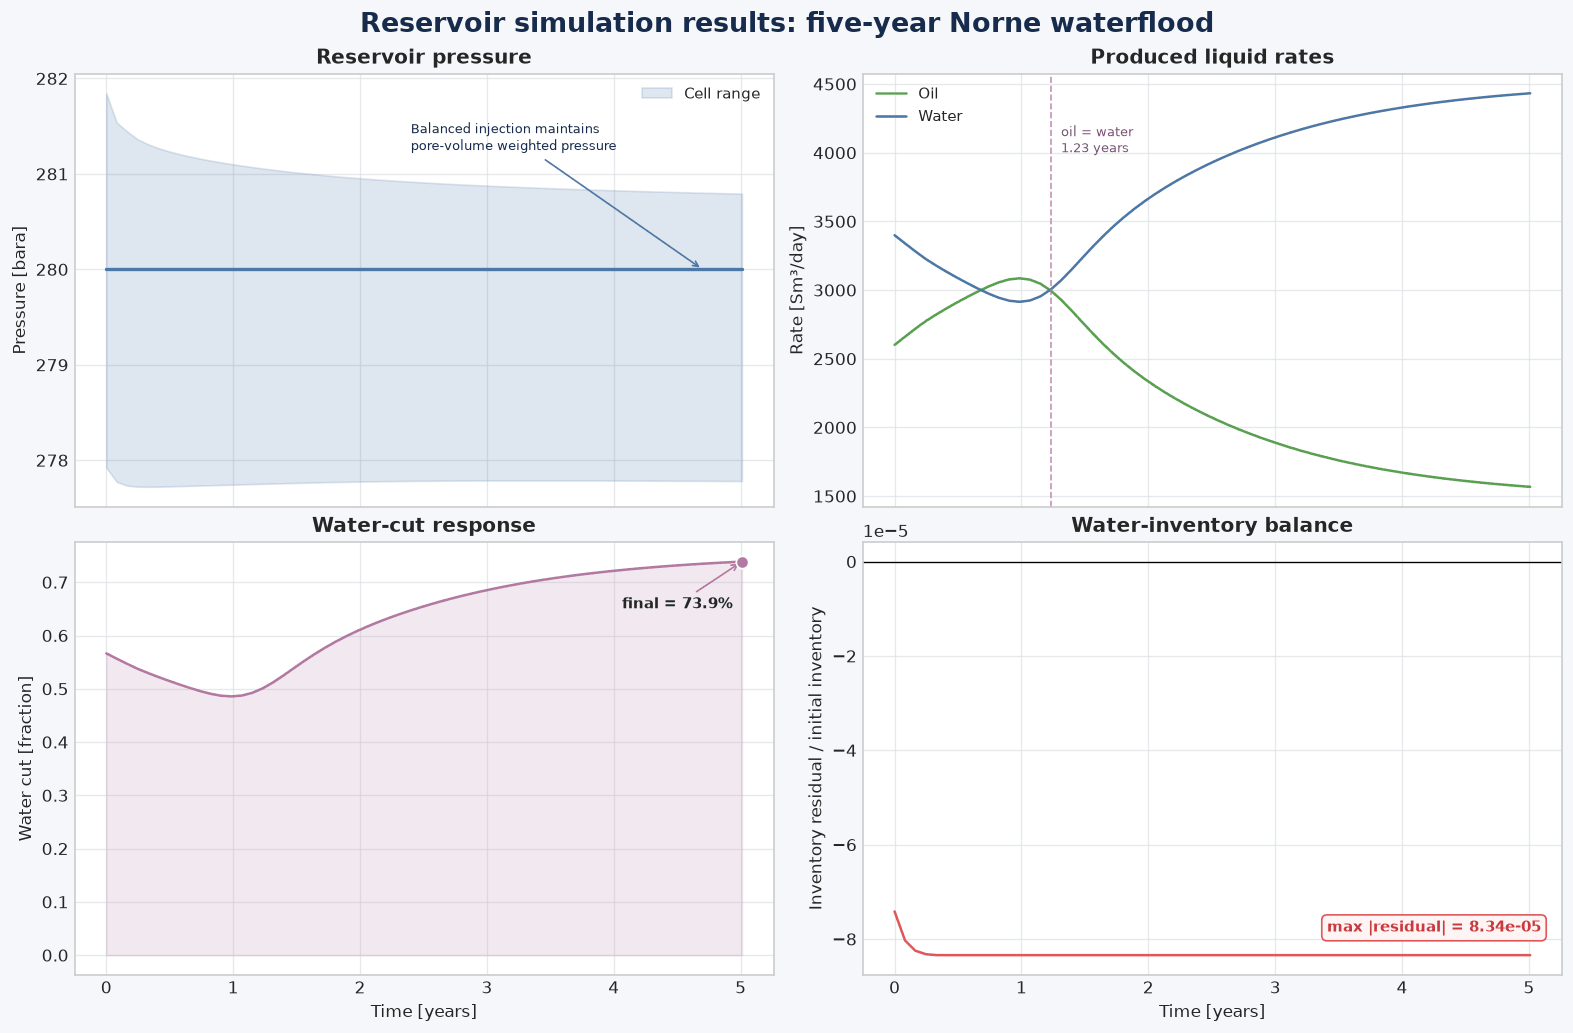

In [15]:
figure, axes = plt.subplots(
    2,
    2,
    figsize=(13, 8.5),
    sharex=True,
    constrained_layout=True,
)
figure.patch.set_facecolor("#F5F7FA")
for axis in axes.flat:
    axis.set_facecolor("white")
    axis.grid(True, color="#DFE1E6", linewidth=0.8, alpha=0.75)
axes[0, 0].plot(
    reservoir_results["time_year"],
    reservoir_results["mean_pressure_bara"],
    color="#4C78A8",
    linewidth=2.0,
)
axes[0, 0].fill_between(
    reservoir_results["time_year"],
    reservoir_results["minimum_pressure_bara"],
    reservoir_results["maximum_pressure_bara"],
    color="#4C78A8",
    alpha=0.18,
    label="Cell range",
)
axes[0, 0].set_ylabel("Pressure [bara]")
axes[0, 0].set_title("Reservoir pressure", weight="bold")
axes[0, 0].legend()
axes[0, 0].annotate(
    "Balanced injection maintains\npore-volume weighted pressure",
    xy=(4.7, reservoir_results["mean_pressure_bara"].iloc[-1]),
    xytext=(2.4, 281.25),
    fontsize=8,
    color="#172B4D",
    arrowprops={"arrowstyle": "->", "color": "#4C78A8"},
)

axes[0, 1].plot(
    reservoir_results["time_year"],
    reservoir_results["oil_rate_sm3_day"],
    color="#59A14F",
    label="Oil",
)
axes[0, 1].plot(
    reservoir_results["time_year"],
    reservoir_results["water_rate_sm3_day"],
    color="#4C78A8",
    label="Water",
)
axes[0, 1].set_ylabel("Rate [Sm³/day]")
axes[0, 1].set_title("Produced liquid rates", weight="bold")
axes[0, 1].legend()
rate_difference = np.abs(
    reservoir_results["oil_rate_sm3_day"]
    - reservoir_results["water_rate_sm3_day"]
)
crossover_index = int(rate_difference.idxmin())
crossover_year = reservoir_results.loc[crossover_index, "time_year"]
axes[0, 1].axvline(
    crossover_year,
    color="#B279A2",
    linestyle="--",
    linewidth=1.0,
    alpha=0.8,
)
axes[0, 1].text(
    crossover_year + 0.08,
    0.92 * axes[0, 1].get_ylim()[1],
    f"oil = water\n{crossover_year:.2f} years",
    fontsize=8,
    color="#7A4E75",
    va="top",
)

axes[1, 0].plot(
    reservoir_results["time_year"],
    reservoir_results["watercut_fraction"],
    color="#B279A2",
)
axes[1, 0].set_ylabel("Water cut [fraction]")
axes[1, 0].set_xlabel("Time [years]")
axes[1, 0].set_title("Water-cut response", weight="bold")
axes[1, 0].fill_between(
    reservoir_results["time_year"],
    0.0,
    reservoir_results["watercut_fraction"],
    color="#B279A2",
    alpha=0.16,
)
final_watercut = reservoir_results["watercut_fraction"].iloc[-1]
axes[1, 0].scatter(
    reservoir_results["time_year"].iloc[-1],
    final_watercut,
    color="#B279A2",
    edgecolor="white",
    s=55,
    zorder=4,
)
axes[1, 0].annotate(
    f"final = {final_watercut:.1%}",
    xy=(reservoir_results["time_year"].iloc[-1], final_watercut),
    xytext=(-72, -28),
    textcoords="offset points",
    fontsize=9,
    weight="bold",
    arrowprops={"arrowstyle": "->", "color": "#B279A2"},
)

axes[1, 1].plot(
    reservoir_results["time_year"],
    reservoir_results["water_balance_fraction"],
    color="#E15759",
)
axes[1, 1].axhline(0.0, color="black", linewidth=0.8)
axes[1, 1].set_ylabel("Inventory residual / initial inventory")
axes[1, 1].set_xlabel("Time [years]")
axes[1, 1].set_title("Water-inventory balance", weight="bold")
maximum_inventory_residual = reservoir_results[
    "water_balance_fraction"
].abs().max()
axes[1, 1].text(
    0.97,
    0.10,
    f"max |residual| = {maximum_inventory_residual:.2e}",
    transform=axes[1, 1].transAxes,
    ha="right",
    fontsize=9,
    weight="bold",
    color="#C53B3E",
    bbox={
        "boxstyle": "round,pad=0.35",
        "facecolor": "#FFF4F4",
        "edgecolor": "#E15759",
    },
)

figure.suptitle(
    "Reservoir simulation results: five-year Norne waterflood",
    fontsize=16,
    weight="bold",
    color="#172B4D",
)
plt.show()

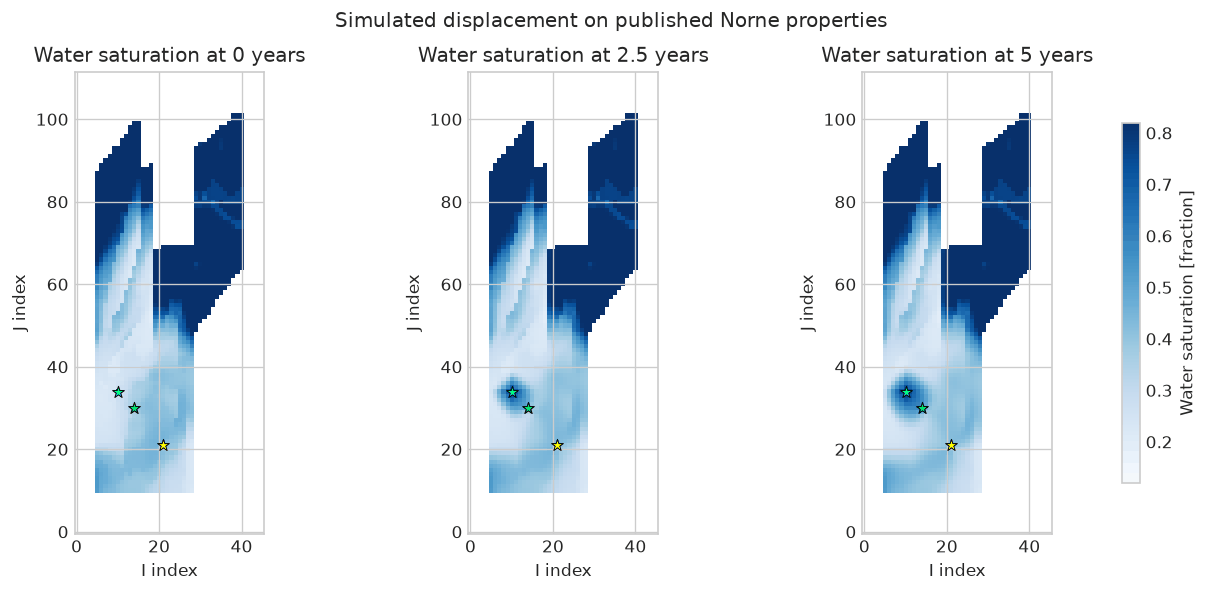

In [16]:
figure, axes = plt.subplots(1, 3, figsize=(15, 5))
for axis, snapshot_year in zip(axes, [0.0, 2.5, 5.0]):
    snapshot_map = np.full((NX, NY), np.nan)
    snapshot_map[active_columns] = saturation_snapshots[snapshot_year]
    image = axis.imshow(
        snapshot_map.T,
        origin="lower",
        cmap="Blues",
        vmin=SW_IRREDUCIBLE,
        vmax=1.0 - SO_RESIDUAL,
    )
    axis.set_title(f"Water saturation at {snapshot_year:g} years")
    axis.set_xlabel("I index")
    axis.set_ylabel("J index")
    for row in wells.itertuples(index=False):
        axis.scatter(
            row.i_eclipse - 1,
            row.j_eclipse - 1,
            s=55,
            marker="*",
            color=well_colors[row.well],
            edgecolor="black",
            linewidth=0.6,
        )
colorbar = figure.colorbar(image, ax=axes, shrink=0.78)
colorbar.set_label("Water saturation [fraction]")
figure.suptitle("Simulated displacement on published Norne properties")
plt.show()

In [17]:
reservoir_checks = {
    "source grid has expected size": (
        porosity_3d.size == NX * NY * NZ == 113344
    ),
    "published active-cell count is stable": int(active_3d.sum()) == 44927,
    "porosity is physically bounded": np.all(
        porosity_3d[active_3d] > 0.0
    ) and np.all(porosity_3d[active_3d] < 0.6),
    "permeability is non-negative": np.all(
        permeability_3d_md[active_3d] >= 0.0
    ),
    "pressure remains positive": (
        reservoir_results["minimum_pressure_bara"].min() > 1.0
    ),
    "oil and water rates are non-negative": np.all(
        reservoir_results[["oil_rate_sm3_day", "water_rate_sm3_day"]]
        >= 0.0
    ),
    "balanced total production": np.allclose(
        reservoir_results["oil_rate_sm3_day"]
        + reservoir_results["water_rate_sm3_day"],
        6000.0,
        rtol=1.0e-8,
        atol=1.0e-5,
    ),
    "water inventory closes": (
        reservoir_results["water_balance_fraction"].abs().max()
        < 1.0e-4
    ),
}
reservoir_validation = pd.DataFrame(
    {
        "check": reservoir_checks.keys(),
        "passed": reservoir_checks.values(),
    }
)
display(reservoir_validation)
assert reservoir_validation["passed"].all()

,check,passed
0,source grid has expected size,True
1,published active-cell count is stable,True
2,porosity is physically bounded,True
3,permeability is non-negative,True
4,pressure remains positive,True
5,oil and water rates are non-negative,True
6,balanced total production,True
7,water inventory closes,True


## 7. Export the reduced model to an OPM/Eclipse-style contract

The finite-volume calculation above used NumPy arrays directly. Production workflows pass
the same data through simulator keywords. The next cell writes a compact property include
for the vertically upscaled model. Eclipse ordering uses $I$ as the fastest index.

The full published `NORNE_ATW2013.DATA` deck should be used for a real Norne black-oil run:

```bash
flow NORNE_ATW2013.DATA
```

That full case requires all geometry, fault, PVT, relative-permeability, VFP and schedule
include files. We do not relabel the portable two-phase model as an OPM Flow history match.

In [18]:
def format_grdecl_keyword(keyword, values, values_per_line=8):
    flattened_values = np.asarray(values).flatten(order="F")
    lines = [keyword]
    for start_index in range(0, len(flattened_values), values_per_line):
        chunk = flattened_values[
            start_index : start_index + values_per_line
        ]
        lines.append("  " + " ".join(f"{value:.8g}" for value in chunk))
    lines.append("/")
    return "\n".join(lines)


reduced_include_path = ARTIFACT_DIRECTORY / "NORNE_FMU_REDUCED_PROPERTIES.INC"
reduced_include_text = "\n\n".join(
    [
        "-- Vertically upscaled educational properties from the public Norne case",
        f"-- OPM data commit: {OPM_DATA_COMMIT}",
        format_grdecl_keyword("ACTNUM", active_columns.astype(int)),
        format_grdecl_keyword("PORO", porosity_2d),
        format_grdecl_keyword("PERMX", permeability_2d_md),
        format_grdecl_keyword("PERMY", permeability_2d_md),
        format_grdecl_keyword("PERMZ", 0.10 * permeability_2d_md),
        format_grdecl_keyword("NTG", np.divide(
            net_thickness_m,
            np.maximum(gross_active_thickness_m, 1.0e-12),
        )),
        format_grdecl_keyword("SWATINIT", sw_initial_2d),
    ]
)
reduced_include_path.write_text(
    reduced_include_text + "\n",
    encoding="utf-8",
)
print(f"Wrote {reduced_include_path}")
print("\n".join(reduced_include_text.splitlines()[:18]))

Wrote norne_fmu_workflow_artifacts/NORNE_FMU_REDUCED_PROPERTIES.INC
-- Vertically upscaled educational properties from the public Norne case

-- OPM data commit: eaa2261683a97027e057c2bc49612ad1c86390b3

ACTNUM
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0


## 8. FMU uncertainty model and prior ensemble

FMU represents uncertainty with realizations rather than a single tuned model. The
uncertain parameters below are deliberately low dimensional so the update is visible:

- pore-volume multiplier;
- permeability multiplier;
- well productivity multiplier;
- aquifer/pressure-support multiplier;
- water-breakthrough timing; and
- GOR multiplier.

In a production Norne workflow, the parameter vector would also include spatial fields,
fault multipliers, contacts, relative-permeability curves, PVT uncertainty and well-model
parameters. ERT would instantiate each realization and call OPM Flow.

In [19]:
ENSEMBLE_SIZE = 60
PARAMETER_COLUMNS = [
    "pv_mult",
    "perm_mult",
    "pi_mult",
    "aquifer_mult",
    "water_breakthrough_year",
    "gor_mult",
]
parameter_bounds = pd.DataFrame(
    {
        "parameter": PARAMETER_COLUMNS,
        "minimum": [0.82, 0.60, 0.72, 0.10, 2.00, 0.75],
        "maximum": [1.18, 1.55, 1.25, 1.20, 5.30, 1.30],
        "unit": ["-", "-", "-", "-", "year", "-"],
        "interpretation": [
            "pore-volume multiplier",
            "effective permeability multiplier",
            "producer PI multiplier",
            "pressure-support multiplier",
            "water breakthrough timing",
            "produced gas/oil-ratio multiplier",
        ],
    }
)
display(parameter_bounds)

prior_parameters = pd.DataFrame(
    {
        "realization": np.arange(ENSEMBLE_SIZE),
        "pv_mult": rng.uniform(0.82, 1.18, ENSEMBLE_SIZE),
        "perm_mult": np.exp(rng.normal(0.0, 0.22, ENSEMBLE_SIZE)),
        "pi_mult": np.exp(rng.normal(0.0, 0.12, ENSEMBLE_SIZE)),
        "aquifer_mult": rng.uniform(0.10, 1.20, ENSEMBLE_SIZE),
        "water_breakthrough_year": rng.uniform(
            2.00,
            5.30,
            ENSEMBLE_SIZE,
        ),
        "gor_mult": np.exp(rng.normal(0.0, 0.12, ENSEMBLE_SIZE)),
    }
)
for bounds_row in parameter_bounds.itertuples(index=False):
    prior_parameters[bounds_row.parameter] = np.clip(
        prior_parameters[bounds_row.parameter],
        bounds_row.minimum,
        bounds_row.maximum,
    )
display(prior_parameters.describe().round(4))

,parameter,minimum,maximum,unit,interpretation
0,pv_mult,0.82,1.18,-,pore-volume multiplier
1,perm_mult,0.60,1.55,-,effective permeability multiplier
2,pi_mult,0.72,1.25,-,producer PI multiplier
3,aquifer_mult,0.10,1.20,-,pressure-support multiplier
4,water_breakthrough_year,2.00,5.30,year,water breakthrough timing
5,gor_mult,0.75,1.30,-,produced gas/oil-ratio multiplier


,realization,pv_mult,perm_mult,pi_mult,aquifer_mult,water_breakthrough_year,gor_mult
count,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000,60.0000
mean,29.5000,0.9920,1.0653,0.9748,0.6580,3.6357,1.0022
std,17.4642,0.1081,0.2236,0.1026,0.3273,0.9316,0.1205
min,0.0000,0.8257,0.6000,0.7745,0.1147,2.0956,0.7777
25%,14.7500,0.9038,0.9276,0.8892,0.3454,2.6858,0.9134
50%,29.5000,0.9892,1.0275,0.9726,0.6740,3.6826,0.9951
75%,44.2500,1.0795,1.2238,1.0446,0.9408,4.5064,1.0899
max,59.0000,1.1789,1.5500,1.2306,1.1686,5.1243,1.3000


### Reduced forward model for ensemble teaching

Running the sparse finite-volume solver hundreds of times is possible but slow in a
teaching notebook. FMU projects commonly use response surfaces for screening and reserve
the full simulator for accepted workflows. Here, a transparent nonlinear decline model is
anchored to the finite-volume result and used for ES-MDA.

This separation is explicit:

- the **published-data finite-volume model** proves the reservoir setup and physical data
  path;
- the **reduced model** makes the ensemble update fast and inspectable; and
- the generated ERT files identify where full OPM Flow replaces the reduced model.

In [20]:
ENSEMBLE_TIME_YEARS = np.arange(0.0, 12.01, 0.25)
BASE_OIL_RATE_SM3_DAY = float(
    reservoir_results.iloc[0]["oil_rate_sm3_day"]
)
BASE_RESERVOIR_PRESSURE_BARA = float(
    reservoir_results.iloc[0]["mean_pressure_bara"]
)


def simulate_reduced_reservoir(parameter_vector):
    (
        pv_mult,
        perm_mult,
        pi_mult,
        aquifer_mult,
        water_breakthrough_year,
        gor_mult,
    ) = parameter_vector
    pressure_decay = (
        0.11
        / (pv_mult * (0.72 + 0.38 * aquifer_mult))
    )
    pressure_bara = 65.0 + (
        BASE_RESERVOIR_PRESSURE_BARA - 65.0
    ) * np.exp(-pressure_decay * ENSEMBLE_TIME_YEARS)
    pressure_drawdown_factor = np.clip(
        (pressure_bara - 65.0)
        / (BASE_RESERVOIR_PRESSURE_BARA - 65.0),
        0.0,
        1.0,
    )
    oil_rate_sm3_day = (
        BASE_OIL_RATE_SM3_DAY
        * np.sqrt(perm_mult)
        * pi_mult
        * pressure_drawdown_factor ** 0.80
        * np.exp(-0.025 * ENSEMBLE_TIME_YEARS)
    )
    watercut_fraction = 0.04 + 0.70 / (
        1.0
        + np.exp(
            -(
                ENSEMBLE_TIME_YEARS
                - water_breakthrough_year
            )
            / 0.72
        )
    )
    water_rate_sm3_day = (
        oil_rate_sm3_day
        * watercut_fraction
        / np.maximum(1.0 - watercut_fraction, 1.0e-6)
    )
    liberated_gas_factor = 1.0 + 0.75 * np.maximum(
        205.0 - pressure_bara,
        0.0,
    ) / 140.0
    gas_rate_sm3_day = (
        oil_rate_sm3_day
        * 145.0
        * gor_mult
        * liberated_gas_factor
    )
    return pd.DataFrame(
        {
            "time_year": ENSEMBLE_TIME_YEARS,
            "pressure_bara": pressure_bara,
            "oil_rate_sm3_day": oil_rate_sm3_day,
            "water_rate_sm3_day": water_rate_sm3_day,
            "gas_rate_sm3_day": gas_rate_sm3_day,
            "watercut_fraction": watercut_fraction,
        }
    )


def simulate_parameter_table(parameter_table):
    frames = []
    for row in parameter_table.itertuples(index=False):
        parameter_vector = np.asarray(
            [getattr(row, name) for name in PARAMETER_COLUMNS],
            dtype=float,
        )
        realization_frame = simulate_reduced_reservoir(parameter_vector)
        realization_frame["realization"] = int(row.realization)
        frames.append(realization_frame)
    return pd.concat(frames, ignore_index=True)


prior_forecasts = simulate_parameter_table(prior_parameters)
display(prior_forecasts.head())

,time_year,pressure_bara,oil_rate_sm3_day,water_rate_sm3_day,gas_rate_sm3_day,watercut_fraction,realization
0,0.00,280.000000,2877.175419,216.018215,397499.538348,0.069837,0
1,0.25,272.918448,2783.656563,246.960844,384579.331197,0.081489,0
2,0.50,266.070144,2693.177415,290.297986,372079.078629,0.097302,0
3,0.75,259.447406,2605.639175,350.023477,359985.130564,0.118425,0
4,1.00,253.042804,2520.946251,431.150742,348284.280603,0.146049,0


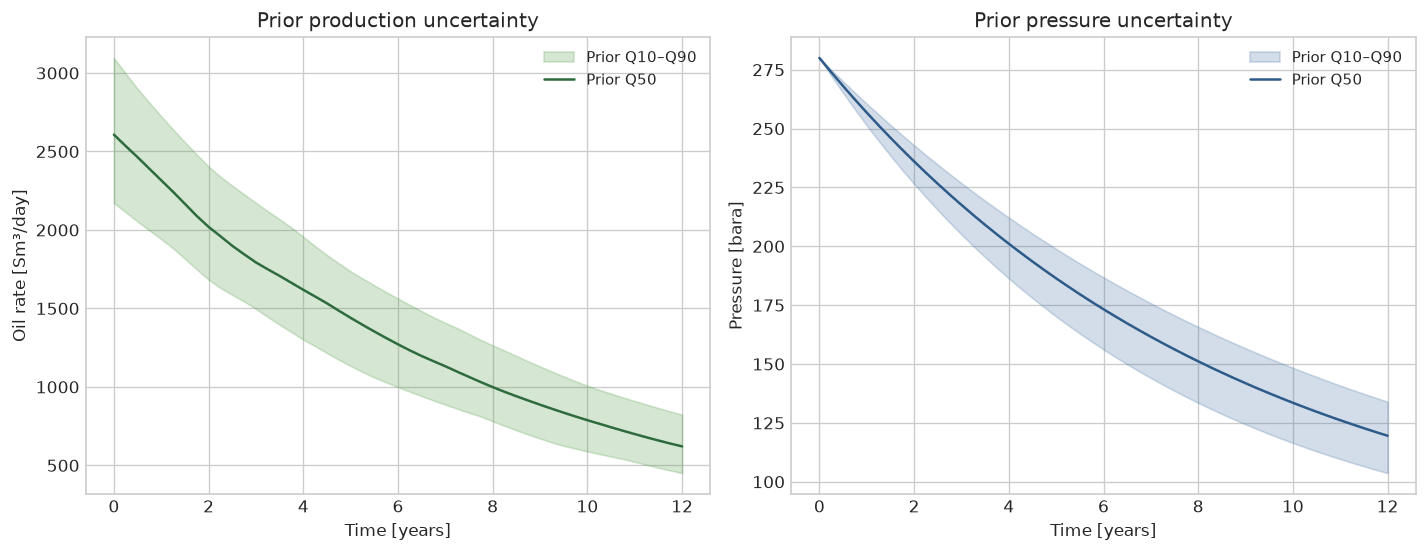

In [21]:
def ensemble_quantiles(frame, value_column):
    quantiles = (
        frame.groupby("time_year")[value_column]
        .quantile([0.10, 0.50, 0.90])
        .unstack()
        .reset_index()
    )
    quantiles.columns = ["time_year", "q10", "q50", "q90"]
    return quantiles


prior_oil_quantiles = ensemble_quantiles(
    prior_forecasts,
    "oil_rate_sm3_day",
)
prior_pressure_quantiles = ensemble_quantiles(
    prior_forecasts,
    "pressure_bara",
)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.7))
axes[0].fill_between(
    prior_oil_quantiles["time_year"],
    prior_oil_quantiles["q10"],
    prior_oil_quantiles["q90"],
    color="#59A14F",
    alpha=0.25,
    label="Prior Q10–Q90",
)
axes[0].plot(
    prior_oil_quantiles["time_year"],
    prior_oil_quantiles["q50"],
    color="#2E6B3D",
    label="Prior Q50",
)
axes[0].set_xlabel("Time [years]")
axes[0].set_ylabel("Oil rate [Sm³/day]")
axes[0].set_title("Prior production uncertainty")
axes[0].legend()

axes[1].fill_between(
    prior_pressure_quantiles["time_year"],
    prior_pressure_quantiles["q10"],
    prior_pressure_quantiles["q90"],
    color="#4C78A8",
    alpha=0.25,
    label="Prior Q10–Q90",
)
axes[1].plot(
    prior_pressure_quantiles["time_year"],
    prior_pressure_quantiles["q50"],
    color="#2D5B8A",
    label="Prior Q50",
)
axes[1].set_xlabel("Time [years]")
axes[1].set_ylabel("Pressure [bara]")
axes[1].set_title("Prior pressure uncertainty")
axes[1].legend()
figure.tight_layout()
plt.show()

## 9. History observations and ES-MDA update

The public property model is real; the measurements in this section are synthetic. A hidden
parameter vector generates observations at six history times, and Gaussian noise is added
with stated standard deviations. This makes the example reproducible without claiming that
these numbers are Norne field history.

ES-MDA applies several weaker updates. In ensemble form, a generic update is

$$X_a=X_f+C_{xy}(C_{yy}+\alpha R)^{-1}(D-Y)$$

where $X$ is the parameter ensemble, $Y$ contains simulated observations, $D$ contains
perturbed observations, $R$ is observation-error covariance and $\alpha$ is the
assimilation inflation factor. The implementation below comes from Equinor's open-source
`iterative-ensemble-smoother` package used by ERT.

In [22]:
history_times_year = np.asarray([0.5, 1.0, 2.0, 3.0, 4.0, 5.0])
history_indices = np.searchsorted(
    ENSEMBLE_TIME_YEARS,
    history_times_year,
)
hidden_truth = np.asarray([1.08, 1.28, 0.94, 0.88, 3.10, 1.11])
truth_forecast = simulate_reduced_reservoir(hidden_truth)

clean_observation_vector = np.concatenate(
    [
        truth_forecast["pressure_bara"].to_numpy()[history_indices],
        truth_forecast["oil_rate_sm3_day"].to_numpy()[history_indices],
        truth_forecast["water_rate_sm3_day"].to_numpy()[history_indices],
        truth_forecast["gas_rate_sm3_day"].to_numpy()[history_indices],
    ]
)
observation_standard_deviation = np.concatenate(
    [
        np.full(len(history_indices), 2.0),
        np.full(len(history_indices), 120.0),
        np.maximum(
            truth_forecast["water_rate_sm3_day"].to_numpy()[history_indices]
            * 0.05,
            60.0,
        ),
        np.maximum(
            truth_forecast["gas_rate_sm3_day"].to_numpy()[history_indices]
            * 0.04,
            15000.0,
        ),
    ]
)
observation_vector = clean_observation_vector + rng.normal(
    0.0,
    observation_standard_deviation,
)

observation_table = pd.DataFrame(
    {
        "time_year": np.tile(history_times_year, 4),
        "response": np.repeat(
            ["pressure", "oil rate", "water rate", "gas rate"],
            len(history_times_year),
        ),
        "observed_value": observation_vector,
        "standard_deviation": observation_standard_deviation,
    }
)
display(observation_table.head(12).round(3))

,time_year,response,observed_value,standard_deviation
0,0.5,pressure,272.332,2.0
1,1.0,pressure,256.830,2.0
2,2.0,pressure,241.274,2.0
3,3.0,pressure,225.744,2.0
4,4.0,pressure,209.833,2.0
5,5.0,pressure,200.381,2.0
6,0.5,oil rate,2720.928,120.0
7,1.0,oil rate,2580.220,120.0
8,2.0,oil rate,2232.708,120.0
9,3.0,oil rate,1959.090,120.0


In [23]:
def response_matrix(parameter_matrix_by_realization):
    response_rows = []
    for parameter_vector in parameter_matrix_by_realization:
        forecast = simulate_reduced_reservoir(parameter_vector)
        response_rows.append(
            np.concatenate(
                [
                    forecast["pressure_bara"].to_numpy()[history_indices],
                    forecast["oil_rate_sm3_day"].to_numpy()[history_indices],
                    forecast["water_rate_sm3_day"].to_numpy()[history_indices],
                    forecast["gas_rate_sm3_day"].to_numpy()[history_indices],
                ]
            )
        )
    return np.asarray(response_rows)


def normalized_ensemble_mean_rmse(parameter_matrix_by_realization):
    predicted_mean = response_matrix(
        parameter_matrix_by_realization
    ).mean(axis=0)
    normalized_residual = (
        predicted_mean - observation_vector
    ) / observation_standard_deviation
    return float(np.sqrt(np.mean(normalized_residual ** 2)))


prior_matrix = prior_parameters[PARAMETER_COLUMNS].to_numpy()
parameter_matrix = prior_matrix.T
esmda = ESMDA(
    covariance=observation_standard_deviation ** 2,
    observations=observation_vector,
    alpha=4,
    seed=RANDOM_SEED,
)
update_rows = [
    {
        "assimilation": 0,
        "normalized_rmse": normalized_ensemble_mean_rmse(prior_matrix),
    }
]

lower_bounds = parameter_bounds["minimum"].to_numpy()[:, None]
upper_bounds = parameter_bounds["maximum"].to_numpy()[:, None]
for assimilation_index in range(esmda.num_assimilations()):
    simulated_observations = response_matrix(parameter_matrix.T).T
    esmda.prepare_assimilation(Y=simulated_observations)
    parameter_matrix = esmda.assimilate_batch(X=parameter_matrix)
    parameter_matrix = np.clip(
        parameter_matrix,
        lower_bounds,
        upper_bounds,
    )
    update_rows.append(
        {
            "assimilation": assimilation_index + 1,
            "normalized_rmse": normalized_ensemble_mean_rmse(
                parameter_matrix.T
            ),
        }
    )

posterior_parameters = pd.DataFrame(
    parameter_matrix.T,
    columns=PARAMETER_COLUMNS,
)
posterior_parameters.insert(
    0,
    "realization",
    np.arange(ENSEMBLE_SIZE),
)
update_audit = pd.DataFrame(update_rows)
display(update_audit.round(4))

,assimilation,normalized_rmse
0,0,4.0734
1,1,0.9932
2,2,0.9480
3,3,0.9329
4,4,0.9304


,parameter,hidden_truth,prior_mean,posterior_mean,prior_std,posterior_std
0,pv_mult,1.08,0.9920,1.0638,0.1081,0.0704
1,perm_mult,1.28,1.0653,1.0963,0.2236,0.1399
2,pi_mult,0.94,0.9748,1.0494,0.1026,0.0599
3,aquifer_mult,0.88,0.6580,0.8945,0.3273,0.1897
4,water_breakthrough_year,3.10,3.6357,3.1723,0.9316,0.0592
5,gor_mult,1.11,1.0022,1.1243,0.1205,0.0306


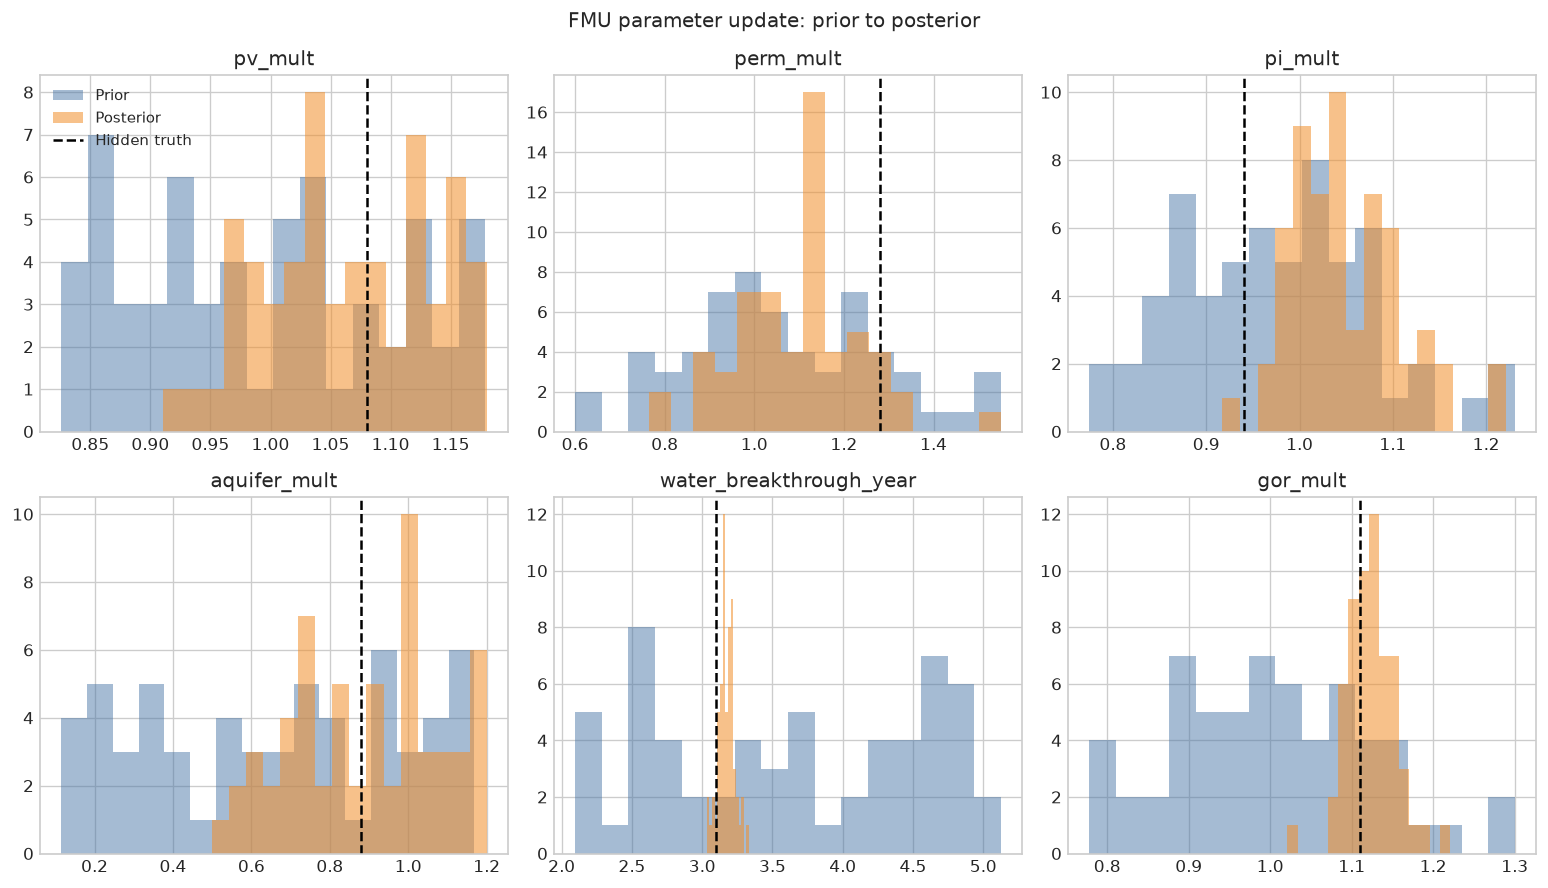

In [24]:
parameter_comparison_rows = []
for parameter_index, parameter_name in enumerate(PARAMETER_COLUMNS):
    parameter_comparison_rows.append(
        {
            "parameter": parameter_name,
            "hidden_truth": hidden_truth[parameter_index],
            "prior_mean": prior_parameters[parameter_name].mean(),
            "posterior_mean": posterior_parameters[parameter_name].mean(),
            "prior_std": prior_parameters[parameter_name].std(),
            "posterior_std": posterior_parameters[parameter_name].std(),
        }
    )
parameter_comparison = pd.DataFrame(parameter_comparison_rows)
display(parameter_comparison.round(4))

figure, axes = plt.subplots(2, 3, figsize=(13, 7.5))
for axis, parameter_name, truth_value in zip(
    axes.flat,
    PARAMETER_COLUMNS,
    hidden_truth,
):
    axis.hist(
        prior_parameters[parameter_name],
        bins=16,
        alpha=0.50,
        color="#4C78A8",
        label="Prior",
    )
    axis.hist(
        posterior_parameters[parameter_name],
        bins=16,
        alpha=0.55,
        color="#F28E2B",
        label="Posterior",
    )
    axis.axvline(
        truth_value,
        color="black",
        linestyle="--",
        label="Hidden truth",
    )
    axis.set_title(parameter_name)
axes[0, 0].legend()
figure.suptitle("FMU parameter update: prior to posterior")
figure.tight_layout()
plt.show()

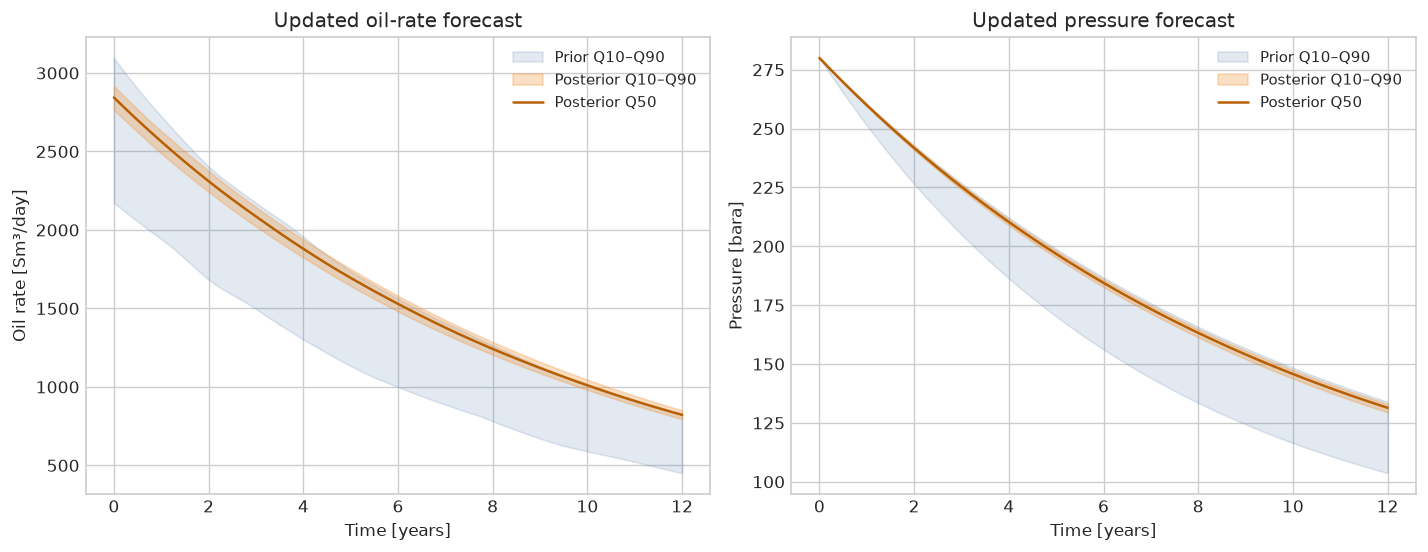

In [25]:
posterior_forecasts = simulate_parameter_table(posterior_parameters)
posterior_oil_quantiles = ensemble_quantiles(
    posterior_forecasts,
    "oil_rate_sm3_day",
)
posterior_pressure_quantiles = ensemble_quantiles(
    posterior_forecasts,
    "pressure_bara",
)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.7))
axes[0].fill_between(
    prior_oil_quantiles["time_year"],
    prior_oil_quantiles["q10"],
    prior_oil_quantiles["q90"],
    color="#4C78A8",
    alpha=0.16,
    label="Prior Q10–Q90",
)
axes[0].fill_between(
    posterior_oil_quantiles["time_year"],
    posterior_oil_quantiles["q10"],
    posterior_oil_quantiles["q90"],
    color="#F28E2B",
    alpha=0.28,
    label="Posterior Q10–Q90",
)
axes[0].plot(
    posterior_oil_quantiles["time_year"],
    posterior_oil_quantiles["q50"],
    color="#B85F00",
    label="Posterior Q50",
)
axes[0].set_xlabel("Time [years]")
axes[0].set_ylabel("Oil rate [Sm³/day]")
axes[0].set_title("Updated oil-rate forecast")
axes[0].legend()

axes[1].fill_between(
    prior_pressure_quantiles["time_year"],
    prior_pressure_quantiles["q10"],
    prior_pressure_quantiles["q90"],
    color="#4C78A8",
    alpha=0.16,
    label="Prior Q10–Q90",
)
axes[1].fill_between(
    posterior_pressure_quantiles["time_year"],
    posterior_pressure_quantiles["q10"],
    posterior_pressure_quantiles["q90"],
    color="#F28E2B",
    alpha=0.28,
    label="Posterior Q10–Q90",
)
axes[1].plot(
    posterior_pressure_quantiles["time_year"],
    posterior_pressure_quantiles["q50"],
    color="#B85F00",
    label="Posterior Q50",
)
axes[1].set_xlabel("Time [years]")
axes[1].set_ylabel("Pressure [bara]")
axes[1].set_title("Updated pressure forecast")
axes[1].legend()
figure.tight_layout()
plt.show()

### Quantile convention

The plots use mathematical quantiles **Q10, Q50 and Q90**. Q10 is the lower 10th
percentile of the plotted variable and Q90 is the upper 90th percentile. This avoids the
petroleum-industry P10/P90 ambiguity, where P10 is often used for a high reserves outcome.

## 10. FMU case structure, metadata and ERT contract

An FMU run needs more than parameter values. Every realization should be traceable to its
source data, code version, iteration, parameter set and result metadata. `fmu-dataio`
automates standard exports in a production FMU environment. Here we create a compact,
inspectable equivalent without connecting to internal storage services.

In [26]:
FMU_CASE_DIRECTORY = ARTIFACT_DIRECTORY / "fmu_case"
FMU_CASE_DIRECTORY.mkdir(exist_ok=True)
(FMU_CASE_DIRECTORY / "share" / "results" / "tables").mkdir(
    parents=True,
    exist_ok=True,
)
(FMU_CASE_DIRECTORY / "ert").mkdir(exist_ok=True)

prior_parameters.to_csv(
    FMU_CASE_DIRECTORY / "share" / "results" / "tables" / "prior.csv",
    index=False,
)
posterior_parameters.to_csv(
    FMU_CASE_DIRECTORY
    / "share"
    / "results"
    / "tables"
    / "posterior.csv",
    index=False,
)
posterior_forecasts.to_csv(
    FMU_CASE_DIRECTORY
    / "share"
    / "results"
    / "tables"
    / "posterior_forecast.csv",
    index=False,
)

metadata = {
    "schema": "educational-fmu-metadata-1.0",
    "case": {
        "name": "norne-public-data-fmu-neqsim",
        "description": (
            "Educational FMU workflow using published Norne properties"
        ),
        "country": "Norway",
        "basin": "Norwegian Sea",
    },
    "source": {
        "repository": "OPM/opm-data",
        "commit": OPM_DATA_COMMIT,
        "license": "ODbL 1.0 / DbCL 1.0 notices in source files",
        "files": source_manifest[
            ["file", "sha256", "source"]
        ].to_dict(orient="records"),
    },
    "ensemble": {
        "size": ENSEMBLE_SIZE,
        "algorithm": "ES-MDA",
        "assimilations": int(esmda.num_assimilations()),
        "random_seed": RANDOM_SEED,
    },
    "software": runtime_versions.to_dict(orient="records"),
}
metadata_path = FMU_CASE_DIRECTORY / "share" / "metadata.json"
metadata_path.parent.mkdir(parents=True, exist_ok=True)
metadata_path.write_text(
    json.dumps(metadata, indent=2),
    encoding="utf-8",
)
print(metadata_path.read_text(encoding="utf-8")[:1600])

{
  "schema": "educational-fmu-metadata-1.0",
  "case": {
    "name": "norne-public-data-fmu-neqsim",
    "description": "Educational FMU workflow using published Norne properties",
    "country": "Norway",
    "basin": "Norwegian Sea"
  },
  "source": {
    "repository": "OPM/opm-data",
    "commit": "eaa2261683a97027e057c2bc49612ad1c86390b3",
    "license": "ODbL 1.0 / DbCL 1.0 notices in source files",
    "files": [
      {
        "file": "NORNE_ATW2013.DATA",
        "sha256": "f346c910f68a80b41ee54606bd434dc9e2993fffa7a2469235f396c2c0a9e080",
        "source": "https://raw.githubusercontent.com/OPM/opm-data/eaa2261683a97027e057c2bc49612ad1c86390b3/norne/NORNE_ATW2013.DATA"
      },
      {
        "file": "PORO_0704.prop",
        "sha256": "e5147647a2fbee651b9df27e1db4a7a70e8b3ee8231b92f93f7fb6a69a03e8cd",
        "source": "https://raw.githubusercontent.com/OPM/opm-data/eaa2261683a97027e057c2bc49612ad1c86390b3/norne/INCLUDE/PETRO/PORO_0704.prop"
      },
      {
        "file"

In [27]:
ert_directory = FMU_CASE_DIRECTORY / "ert"
prior_lines = []
for row in parameter_bounds.itertuples(index=False):
    keyword = row.parameter.upper()
    prior_lines.append(
        f"{keyword} UNIFORM {row.minimum:.12g} {row.maximum:.12g}"
    )
(ert_directory / "parameter_priors.txt").write_text(
    "\n".join(prior_lines) + "\n",
    encoding="utf-8",
)

forward_model_lines = [
    "#!/usr/bin/env python",
    "import json",
    "from pathlib import Path",
    "",
    "parameters = json.loads(Path('parameters.json').read_text())",
    "pv_mult = float(parameters['PV_MULT']['value'])",
    "perm_mult = float(parameters['PERM_MULT']['value'])",
    "pi_mult = float(parameters['PI_MULT']['value'])",
    "response = pv_mult * perm_mult ** 0.5 * pi_mult",
    "Path('response.out').write_text(f'{response:.12g}\\n')",
]
forward_model_path = ert_directory / "forward_model.py"
forward_model_path.write_text(
    "\n".join(forward_model_lines) + "\n",
    encoding="utf-8",
)
forward_model_path.chmod(0o755)

job_text = "\n".join(
    [
        "EXECUTABLE forward_model.py",
        "TARGET_FILE response.out",
    ]
)
(ert_directory / "NORNE_REDUCED").write_text(
    job_text + "\n",
    encoding="utf-8",
)

ert_configuration = f'''NUM_REALIZATIONS {ENSEMBLE_SIZE}
MIN_REALIZATIONS {ENSEMBLE_SIZE}
RANDOM_SEED {RANDOM_SEED}

QUEUE_SYSTEM LOCAL
QUEUE_OPTION LOCAL MAX_RUNNING 2

RUNPATH runs/realization-<IENS>/iter-<ITER>
GEN_KW RESERVOIR parameter_priors.txt
GEN_DATA RESERVOIR_RESPONSE RESULT_FILE:response.out

INSTALL_JOB NORNE_REDUCED NORNE_REDUCED
FORWARD_MODEL NORNE_REDUCED
'''
ert_configuration = textwrap.dedent(ert_configuration)
ert_config_path = ert_directory / "norne_fmu.ert"
ert_config_path.write_text(ert_configuration, encoding="utf-8")
print(ert_configuration)

NUM_REALIZATIONS 60
MIN_REALIZATIONS 60
RANDOM_SEED 20260820

QUEUE_SYSTEM LOCAL
QUEUE_OPTION LOCAL MAX_RUNNING 2

RUNPATH runs/realization-<IENS>/iter-<ITER>
GEN_KW RESERVOIR parameter_priors.txt
GEN_DATA RESERVOIR_RESPONSE RESULT_FILE:response.out

INSTALL_JOB NORNE_REDUCED NORNE_REDUCED
FORWARD_MODEL NORNE_REDUCED



In [28]:
ert_lint = subprocess.run(
    ["ert", "lint", "norne_fmu.ert"],
    cwd=ert_directory,
    capture_output=True,
    text=True,
    timeout=120,
)
print(ert_lint.stdout.strip())
if ert_lint.stderr.strip():
    print(ert_lint.stderr.strip())
if ert_lint.returncode != 0:
    raise RuntimeError("The generated ERT configuration did not pass lint.")

Found no errors


## 11. Posterior reservoir-to-NeqSim interface

A process simulator needs a unit-labelled contract, not an unlabeled array. For each
realization and report time, the minimum handover is:

- reservoir and wellhead pressure in absolute units;
- temperature;
- standard oil, gas and water rates;
- fluid composition or PVT identifier;
- realization, iteration and report time; and
- quality flags and convergence status.

Three posterior cases at year five are selected by the mathematical Q10, Q50 and Q90 of
oil rate. They are then run through a real NeqSim three-phase inlet, choke, cooler,
separator and export compressor.

In [29]:
PROCESS_REPORT_YEAR = 5.0
process_candidates = posterior_forecasts[
    np.isclose(
        posterior_forecasts["time_year"],
        PROCESS_REPORT_YEAR,
    )
].copy()
target_quantiles = process_candidates["oil_rate_sm3_day"].quantile(
    [0.10, 0.50, 0.90]
)

representative_rows = []
for quantile_label, target_value in zip(
    ["Q10 low", "Q50 median", "Q90 high"],
    target_quantiles.to_numpy(),
):
    closest_index = (
        process_candidates["oil_rate_sm3_day"] - target_value
    ).abs().idxmin()
    selected_row = process_candidates.loc[closest_index].to_dict()
    selected_row["case"] = quantile_label
    selected_row["wellhead_pressure_bara"] = max(
        45.0,
        0.35 * selected_row["pressure_bara"],
    )
    selected_row["temperature_C"] = 60.0
    representative_rows.append(selected_row)

process_interface = pd.DataFrame(representative_rows)
process_interface = process_interface[
    [
        "case",
        "realization",
        "time_year",
        "pressure_bara",
        "wellhead_pressure_bara",
        "temperature_C",
        "oil_rate_sm3_day",
        "gas_rate_sm3_day",
        "water_rate_sm3_day",
    ]
]
process_interface.to_csv(
    ARTIFACT_DIRECTORY / "reservoir_to_neqsim.csv",
    index=False,
)
display(process_interface.round(3))

,case,realization,time_year,pressure_bara,wellhead_pressure_bara,temperature_C,oil_rate_sm3_day,gas_rate_sm3_day,water_rate_sm3_day
0,Q10 low,41.0,5.0,194.945,68.231,60.0,1643.135,285386.206,3660.833
1,Q50 median,18.0,5.0,198.293,69.403,60.0,1692.862,289205.725,3773.665
2,Q90 high,15.0,5.0,198.381,69.433,60.0,1751.579,289406.394,3817.816


In [30]:
from neqsim.thermo.thermoTools import fluid
from neqsim.process.processTools import (
    clearProcess,
    compressor,
    heater,
    mixer,
    runProcess,
    separator3phase,
    stream,
    valve,
)


COMPONENTS = [
    "nitrogen",
    "CO2",
    "methane",
    "ethane",
    "propane",
    "i-butane",
    "n-butane",
    "n-pentane",
    "n-hexane",
    "n-heptane",
    "n-nonane",
    "nC10",
    "water",
]
GAS_COMPOSITION = {
    "nitrogen": 0.015,
    "CO2": 0.025,
    "methane": 0.820,
    "ethane": 0.070,
    "propane": 0.035,
    "i-butane": 0.008,
    "n-butane": 0.012,
    "n-pentane": 0.005,
    "n-hexane": 0.004,
    "n-heptane": 0.003,
    "n-nonane": 0.002,
    "nC10": 0.001,
    "water": 1.0e-8,
}
OIL_COMPOSITION = {
    "nitrogen": 0.001,
    "CO2": 0.002,
    "methane": 0.030,
    "ethane": 0.040,
    "propane": 0.060,
    "i-butane": 0.040,
    "n-butane": 0.080,
    "n-pentane": 0.100,
    "n-hexane": 0.140,
    "n-heptane": 0.180,
    "n-nonane": 0.170,
    "nC10": 0.157,
    "water": 1.0e-8,
}
WATER_COMPOSITION = {
    component_name: (
        1.0 if component_name == "water" else 1.0e-12
    )
    for component_name in COMPONENTS
}


def build_neqsim_fluid(composition):
    thermo_system = fluid("srk")
    for component_name in COMPONENTS:
        thermo_system.addComponent(
            component_name,
            float(composition.get(component_name, 1.0e-12)),
        )
    thermo_system.setMixingRule(2)
    thermo_system.setMultiPhaseCheck(True)
    return thermo_system

In [31]:
def run_neqsim_facility_case(case_row):
    clearProcess()
    inlet_pressure_bara = float(case_row.wellhead_pressure_bara)
    inlet_temperature_c = float(case_row.temperature_C)

    gas_stream = stream(
        "reservoir gas",
        build_neqsim_fluid(GAS_COMPOSITION),
    )
    gas_stream.setFlowRate(
        float(case_row.gas_rate_sm3_day) / 1.0e6,
        "MSm3/day",
    )
    gas_stream.setTemperature(inlet_temperature_c, "C")
    gas_stream.setPressure(inlet_pressure_bara, "bara")

    oil_stream = stream(
        "reservoir oil",
        build_neqsim_fluid(OIL_COMPOSITION),
    )
    oil_mass_rate_kg_hr = (
        float(case_row.oil_rate_sm3_day) * 830.0 / 24.0
    )
    oil_stream.setFlowRate(oil_mass_rate_kg_hr, "kg/hr")
    oil_stream.setTemperature(inlet_temperature_c, "C")
    oil_stream.setPressure(inlet_pressure_bara, "bara")

    water_stream = stream(
        "reservoir water",
        build_neqsim_fluid(WATER_COMPOSITION),
    )
    water_mass_rate_kg_hr = (
        float(case_row.water_rate_sm3_day) * 1000.0 / 24.0
    )
    water_stream.setFlowRate(water_mass_rate_kg_hr, "kg/hr")
    water_stream.setTemperature(inlet_temperature_c, "C")
    water_stream.setPressure(inlet_pressure_bara, "bara")

    wellstream_mixer = mixer("wellstream mixer")
    wellstream_mixer.addStream(gas_stream)
    wellstream_mixer.addStream(oil_stream)
    wellstream_mixer.addStream(water_stream)

    inlet_choke = valve(
        "inlet choke",
        wellstream_mixer.getOutletStream(),
    )
    inlet_choke.setOutletPressure(35.0, "bara")

    inlet_cooler = heater(
        "inlet cooler",
        inlet_choke.getOutStream(),
    )
    inlet_cooler.setOutTemperature(35.0, "C")

    hp_separator = separator3phase(
        "HP separator",
        inlet_cooler.getOutStream(),
    )
    export_compressor = compressor(
        "export compressor",
        hp_separator.getGasOutStream(),
        120.0,
    )
    export_compressor.setIsentropicEfficiency(0.78)
    runProcess()

    feed_mass_kg_hr = wellstream_mixer.getOutletStream().getFlowRate(
        "kg/hr"
    )
    outlet_mass_kg_hr = sum(
        [
            hp_separator.getGasOutStream().getFlowRate("kg/hr"),
            hp_separator.getOilOutStream().getFlowRate("kg/hr"),
            hp_separator.getWaterOutStream().getFlowRate("kg/hr"),
        ]
    )
    return {
        "case": case_row.case,
        "feed_mass_kg_hr": feed_mass_kg_hr,
        "separator_gas_MSm3_day": (
            hp_separator.getGasOutStream().getFlowRate("MSm3/day")
        ),
        "separator_oil_kg_hr": (
            hp_separator.getOilOutStream().getFlowRate("kg/hr")
        ),
        "separator_water_kg_hr": (
            hp_separator.getWaterOutStream().getFlowRate("kg/hr")
        ),
        "compressor_power_MW": export_compressor.getPower() / 1.0e6,
        "export_pressure_bara": (
            export_compressor.getOutStream().getPressure("bara")
        ),
        "mass_balance_fraction": (
            feed_mass_kg_hr - outlet_mass_kg_hr
        ) / feed_mass_kg_hr,
    }


process_result_rows = [
    run_neqsim_facility_case(row)
    for row in process_interface.itertuples(index=False)
]
neqsim_process_results = pd.DataFrame(process_result_rows)
display(neqsim_process_results.round(6))

,case,feed_mass_kg_hr,separator_gas_MSm3_day,separator_oil_kg_hr,separator_water_kg_hr,compressor_power_MW,export_pressure_bara,mass_balance_fraction
0,Q10 low,219866.151019,0.225589,59459.571250,152510.639558,0.477976,120.0,-0.0
1,Q50 median,226427.807404,0.227711,61247.188778,157211.436096,0.482491,120.0,-0.0
2,Q90 high,230305.480722,0.226010,63347.241802,159050.565876,0.478928,120.0,-0.0


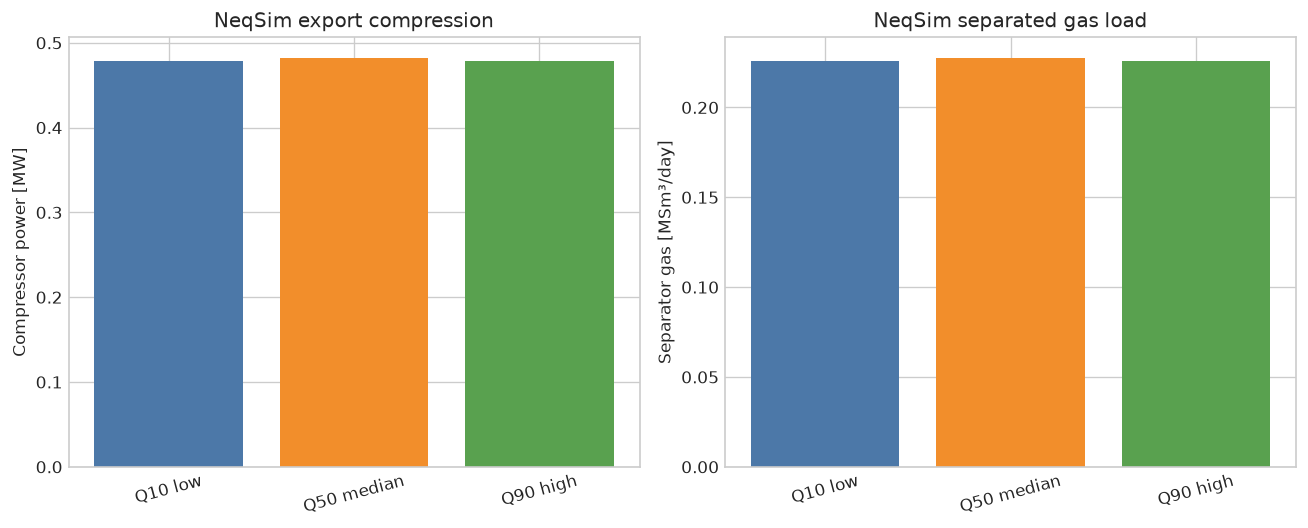

In [32]:
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(
    neqsim_process_results["case"],
    neqsim_process_results["compressor_power_MW"],
    color=["#4C78A8", "#F28E2B", "#59A14F"],
)
axes[0].set_ylabel("Compressor power [MW]")
axes[0].set_title("NeqSim export compression")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(
    neqsim_process_results["case"],
    neqsim_process_results["separator_gas_MSm3_day"],
    color=["#4C78A8", "#F28E2B", "#59A14F"],
)
axes[1].set_ylabel("Separator gas [MSm³/day]")
axes[1].set_title("NeqSim separated gas load")
axes[1].tick_params(axis="x", rotation=15)
figure.tight_layout()
plt.show()

## 12. Facility constraints and feedback to the reservoir model

Facility limits must be evaluated for every posterior realization, not only the median.
The example screens gas export, produced-water handling and compression power at year five.
A simple curtailment factor is returned to the reservoir control layer:

$$u=\min\left(1,\frac{Q_{g,max}}{Q_g},\frac{Q_{w,max}}{Q_w},\frac{P_{max}}{P_{comp}}\right)$$

Production rates are multiplied by $u$. In a real closed loop, the control vector would be
sent back to OPM Flow as well/group constraints and the complete forecast would be rerun.

In [33]:
GAS_CAPACITY_MSM3_DAY = 0.29
WATER_CAPACITY_SM3_DAY = 3800.0
COMPRESSOR_POWER_CAPACITY_MW = 1.50

power_fit = np.polyfit(
    neqsim_process_results["separator_gas_MSm3_day"],
    neqsim_process_results["compressor_power_MW"],
    deg=1,
)
capacity_screen = process_candidates.copy()
capacity_screen["gas_rate_MSm3_day"] = (
    capacity_screen["gas_rate_sm3_day"] / 1.0e6
)
capacity_screen["estimated_power_MW"] = np.maximum(
    np.polyval(power_fit, capacity_screen["gas_rate_MSm3_day"]),
    0.0,
)
capacity_screen["gas_factor"] = np.minimum(
    1.0,
    GAS_CAPACITY_MSM3_DAY
    / np.maximum(capacity_screen["gas_rate_MSm3_day"], 1.0e-12),
)
capacity_screen["water_factor"] = np.minimum(
    1.0,
    WATER_CAPACITY_SM3_DAY
    / np.maximum(capacity_screen["water_rate_sm3_day"], 1.0e-12),
)
capacity_screen["power_factor"] = np.minimum(
    1.0,
    COMPRESSOR_POWER_CAPACITY_MW
    / np.maximum(capacity_screen["estimated_power_MW"], 1.0e-12),
)
capacity_screen["control_factor"] = capacity_screen[
    ["gas_factor", "water_factor", "power_factor"]
].min(axis=1)
capacity_screen["controlled_oil_rate_sm3_day"] = (
    capacity_screen["oil_rate_sm3_day"]
    * capacity_screen["control_factor"]
)
capacity_screen["constrained"] = (
    capacity_screen["control_factor"] < 0.999999
)

capacity_summary = pd.DataFrame(
    {
        "metric": [
            "Posterior realizations",
            "Probability of facility constraint",
            "Median control factor",
            "Q10 controlled oil rate",
            "Q50 controlled oil rate",
            "Q90 controlled oil rate",
        ],
        "value": [
            len(capacity_screen),
            capacity_screen["constrained"].mean(),
            capacity_screen["control_factor"].median(),
            capacity_screen["controlled_oil_rate_sm3_day"].quantile(0.10),
            capacity_screen["controlled_oil_rate_sm3_day"].quantile(0.50),
            capacity_screen["controlled_oil_rate_sm3_day"].quantile(0.90),
        ],
        "unit": ["count", "fraction", "fraction", "Sm³/day", "Sm³/day", "Sm³/day"],
    }
)
display(capacity_summary.round(4))

,metric,value,unit
0,Posterior realizations,60.0000,count
1,Probability of facility constraint,0.5000,fraction
2,Median control factor,0.9999,fraction
3,Q10 controlled oil rate,1642.6160,Sm³/day
4,Q50 controlled oil rate,1687.0138,Sm³/day
5,Q90 controlled oil rate,1737.0836,Sm³/day


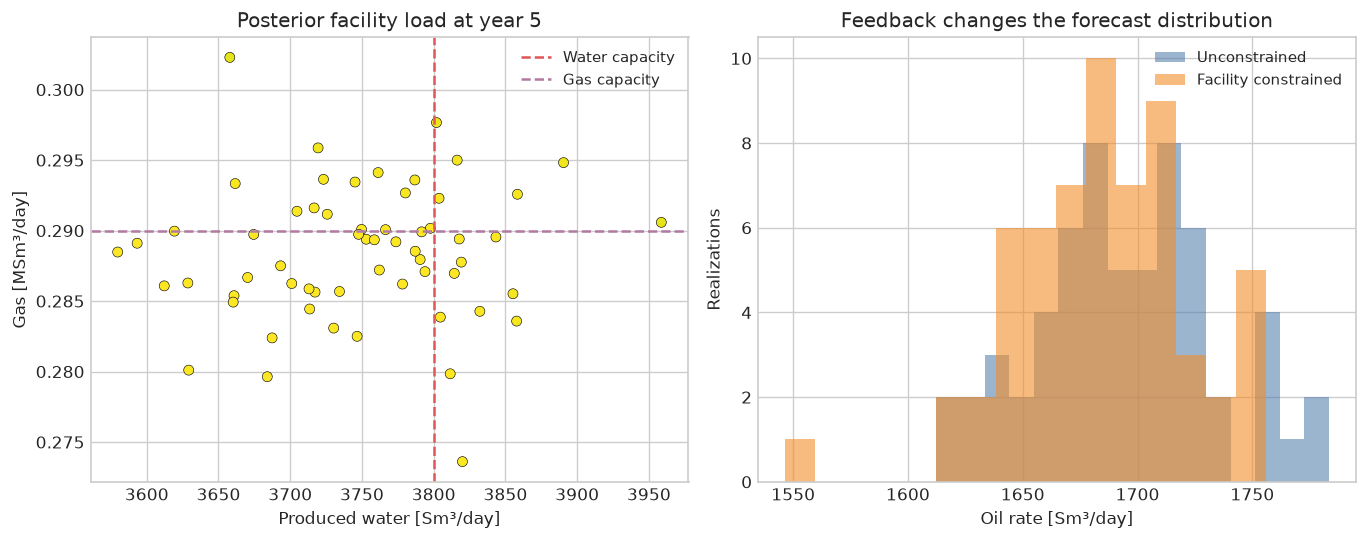

In [34]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
axes[0].scatter(
    capacity_screen["water_rate_sm3_day"],
    capacity_screen["gas_rate_MSm3_day"],
    c=capacity_screen["control_factor"],
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
    edgecolor="black",
    linewidth=0.35,
)
axes[0].axvline(
    WATER_CAPACITY_SM3_DAY,
    color="#E15759",
    linestyle="--",
    label="Water capacity",
)
axes[0].axhline(
    GAS_CAPACITY_MSM3_DAY,
    color="#B279A2",
    linestyle="--",
    label="Gas capacity",
)
axes[0].set_xlabel("Produced water [Sm³/day]")
axes[0].set_ylabel("Gas [MSm³/day]")
axes[0].set_title("Posterior facility load at year 5")
axes[0].legend()

axes[1].hist(
    capacity_screen["oil_rate_sm3_day"],
    bins=16,
    alpha=0.55,
    color="#4C78A8",
    label="Unconstrained",
)
axes[1].hist(
    capacity_screen["controlled_oil_rate_sm3_day"],
    bins=16,
    alpha=0.60,
    color="#F28E2B",
    label="Facility constrained",
)
axes[1].set_xlabel("Oil rate [Sm³/day]")
axes[1].set_ylabel("Realizations")
axes[1].set_title("Feedback changes the forecast distribution")
axes[1].legend()
figure.tight_layout()
plt.show()

## 13. End-to-end validation evidence

The evidence ladder used here is:

1. **Published benchmark provenance:** immutable Norne files and embedded licenses.
2. **Conservation:** water inventory and NeqSim separator mass balance.
3. **Numerical bounds:** positive pressure, bounded saturations and finite ensemble results.
4. **History-update behavior:** posterior normalized mismatch is lower than prior mismatch.
5. **Independent software path:** actual NeqSim thermodynamics and process equipment are run.

A full engineering study should add exact OPM Flow execution, regression against published
Norne summary vectors and well-by-well history data, uncertainty localization, geological
plausibility checks and a calibrated well/facility network.

In [35]:
end_to_end_checks = {
    "all published source files exist": all(
        (DATA_DIRECTORY / file_name).is_file()
        for file_name in source_files
    ),
    "source checksums are unique and populated": (
        source_manifest["sha256"].str.len().eq(64).all()
        and source_manifest["sha256"].is_unique
    ),
    "reservoir validation passed": reservoir_validation["passed"].all(),
    "ES-MDA improves normalized mismatch": (
        update_audit.iloc[-1]["normalized_rmse"]
        < update_audit.iloc[0]["normalized_rmse"]
    ),
    "posterior values are finite": np.isfinite(
        posterior_parameters[PARAMETER_COLUMNS]
    ).all().all(),
    "ERT configuration lint passed": ert_lint.returncode == 0,
    "NeqSim export pressure meets target": np.allclose(
        neqsim_process_results["export_pressure_bara"],
        120.0,
        atol=1.0e-5,
    ),
    "NeqSim separator mass balance closes": (
        neqsim_process_results["mass_balance_fraction"].abs().max()
        < 1.0e-8
    ),
    "facility controls are bounded": capacity_screen[
        "control_factor"
    ].between(0.0, 1.0).all(),
    "interface file exists": (
        ARTIFACT_DIRECTORY / "reservoir_to_neqsim.csv"
    ).is_file(),
    "FMU metadata exists": metadata_path.is_file(),
}
end_to_end_validation = pd.DataFrame(
    {
        "check": end_to_end_checks.keys(),
        "passed": end_to_end_checks.values(),
    }
)
display(end_to_end_validation)
assert end_to_end_validation["passed"].all()
print("All end-to-end validation checks passed.")

All end-to-end validation checks passed.


,check,passed
0,all published source files exist,True
1,source checksums are unique and populated,True
2,reservoir validation passed,True
3,ES-MDA improves normalized mismatch,True
4,posterior values are finite,True
5,ERT configuration lint passed,True
6,NeqSim export pressure meets target,True
7,NeqSim separator mass balance closes,True
8,facility controls are bounded,True
9,interface file exists,True


## 14. Engineering interpretation

The notebook demonstrates why FMU belongs between the static/dynamic subsurface model and
the facilities model:

- published static properties determine connectivity and displacement;
- uncertain parameters generate a distribution of pressure and rates;
- observations reduce some, but not all, uncertainty;
- the posterior ensemble creates a distribution of facility loads;
- NeqSim converts those boundary conditions into thermodynamic and equipment responses; and
- capacity limits alter feasible well controls and therefore the reservoir forecast.

A single deterministic reservoir case would hide both the probability of a bottleneck and
the upside that the facilities may not be able to process. FMU makes this uncertainty
operational: every result retains a realization identity and can be rerun after new data.

### Limitations

- The finite-volume solver is a vertically upscaled two-phase educational model.
- Cell dimensions and layer thickness are assumptions, not the Norne corner-point geometry.
- Gas injection, dissolved gas, vaporized oil, faults, VFP, gravity and capillary pressure
  require the full OPM Flow deck.
- Synthetic observations prove the update mechanics but are not Norne production history.
- ES-MDA uses six global parameters; field projects require spatial updates and localization.
- Process compositions are educational and not Norne fluid samples.
- The facility feedback uses a compact capacity screen, not a network optimizer.
- Results are for education and workflow design, not reserves reporting or design
  certification.

## 15. Suggested extensions

1. Download the complete Norne include tree and run `NORNE_ATW2013.DATA` with OPM Flow.
2. Read OPM summary vectors and replace the synthetic observations with published history.
3. Add fault-transmissibility and relative-permeability uncertainty to ERT.
4. Use field localization and test geological plausibility after each update.
5. Replace the reduced model with one OPM Flow run per realization.
6. Use `fmu-dataio` for standard-result export and richer metadata in an FMU runtime.
7. Add NeqSim well, gathering and multiphase pipeline models before the separator.
8. Optimize well controls under posterior facility and export constraints.
9. Repeat the data-to-model chain with public Volve LAS and SEG-Y data.

## References

- OPM, [Norne open reservoir model](https://github.com/OPM/opm-data/tree/eaa2261683a97027e057c2bc49612ad1c86390b3/norne).
- OPM, [Open datasets](https://opm-project.org/?page_id=559).
- OPM, [Flow reservoir simulator](https://opm-project.org/?page_id=19).
- Equinor, [ERT history-matching introduction](https://ert.readthedocs.io/en/latest/theory/gentle_introduction_to_history_matching.html).
- Equinor, [fmu-dataio overview](https://fmu-dataio.readthedocs.io/en/latest/overview.html).
- Equinor, [fmu-tools documentation](https://equinor.github.io/fmu-tools/).
- Equinor, [NeqSim documentation](https://equinor.github.io/neqsimhome/).
- Equinor, [Volve public data](https://www.equinor.com/energy/volve-data-sharing).

## Saved-notebook validation record

This notebook is intended to be executed top to bottom in a clean Python runtime. The
committed version stores every output, including source hashes, property statistics,
maps, reservoir results, ES-MDA diagnostics, ERT lint output, NeqSim results, capacity
screening and final assertions. The repository notebook checker and an HTML/MathJax render
are run before publication.